In [1]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  

# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd  


# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  

# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  

# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  


# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  

# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  

# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  

# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  

# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  


# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  

# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  

# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  

# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  


# Offers utilities for generating random numbers and sequences.
import random  

# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

### Loading datasets

The code snippet loads `data_train` and `data_test` from: 


In [2]:
train_path = "data/output/01_data_understanding/data_train.csv"
test_path = "data/output/01_data_understanding/data_test.csv"
data_train = pd.read_csv(train_path)
data_test = pd.read_csv(test_path)

print("Datasets loaded successfully.")        # Prints a message if the datasets are loaded successfully.

Datasets loaded successfully.


### Outliers

In [3]:
from scipy.stats import kurtosis, skew

# Initialize an empty dictionary to store the results
results = {'Variable': [], 'Excess Kurtosis': [], 'Skewness': []}

for f in data_train.select_dtypes(include=['int']):
    # Append the results to the dictionary
    results['Variable'].append(f)
    results['Excess Kurtosis'].append(kurtosis(data_train[f]))
    results['Skewness'].append(skew(data_train[f]))

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Print the DataFrame
print(results_df)

            Variable  Excess Kurtosis   Skewness
0             rating         0.657722  -0.620981
1          startYear         1.054699  -1.133720
2           numVotes       958.011370  27.975765
3        totalImages      1045.604347  28.397349
4        totalVideos      3441.174816  49.809506
..               ...              ...        ...
192         Thriller        15.362838   4.166874
193              War        72.096070   8.607907
194          Western        47.692686   7.049304
195       totalMedia      1020.450869  27.971380
196  startYearDecade         1.024096  -1.085927

[197 rows x 3 columns]


In [4]:
def detect_outliers(data, columns_to_check, threshold_std_dev=2.0, threshold_iqr=1.5):
    """
    Identifies potential outliers in the specified columns of a DataFrame using two methods:
    1. Standard deviation.
    2. Interquartile range (IQR).

    Args:
        data (pd.DataFrame): The input DataFrame.
        columns_to_check (list): List of column names to check for outliers.
        threshold_std_dev (float): Multiplier for standard deviation threshold.
        threshold_iqr (float): Multiplier for IQR threshold.

    Returns:
        dict: A dictionary with the following keys:
            - "columns_with_outliers_std_dev": Columns with outliers detected by standard deviation.
            - "columns_with_outliers_iqr": Columns with outliers detected by IQR.
            - "common_outlier_columns": Columns with outliers detected by both methods.
    """
    # Select only the specified columns
    numeric_columns = data[columns_to_check]

    # Calculate quartiles and IQR
    quartiles = numeric_columns.quantile([0.25, 0.75])
    lower_quartile = quartiles.loc[0.25]
    upper_quartile = quartiles.loc[0.75]
    interquartile_range = upper_quartile - lower_quartile

    # Identify outliers using the standard deviation method
    outliers_std_dev = (numeric_columns - numeric_columns.mean()).abs() > threshold_std_dev * numeric_columns.std()

    # Identify outliers using the IQR method
    outliers_iqr = (numeric_columns < lower_quartile - threshold_iqr * interquartile_range) | \
                   (numeric_columns > upper_quartile + threshold_iqr * interquartile_range)

    # Determine columns with outliers for each method
    columns_with_outliers_std_dev = numeric_columns.columns[outliers_std_dev.any()]
    columns_with_outliers_iqr = numeric_columns.columns[outliers_iqr.any()]

    # Find common columns with outliers detected by both methods
    common_outlier_columns = columns_with_outliers_std_dev.intersection(columns_with_outliers_iqr)

    return {
        "columns_with_outliers_std_dev": columns_with_outliers_std_dev.tolist(),
        "columns_with_outliers_iqr": columns_with_outliers_iqr.tolist(),
        "common_outlier_columns": common_outlier_columns.tolist()
    }

# Example usage:
columns_to_check = [
    "runtimeMinutes", 
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "totalRecognitions", 
    "NumberOfGenres"
]

outliers_info = detect_outliers(data_train, columns_to_check)
print("\nColumns with potential outliers detected by standard deviation:")
print(outliers_info["columns_with_outliers_std_dev"])
print("\nColumns with potential outliers detected by IQR:")
print(outliers_info["columns_with_outliers_iqr"])
print("\nColumns with potential outliers detected by both methods:")
print(outliers_info["common_outlier_columns"])



Columns with potential outliers detected by standard deviation:
['runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'totalRecognitions']

Columns with potential outliers detected by IQR:
['runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'totalRecognitions']

Columns with potential outliers detected by both methods:
['runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'totalRecognitions']


# Correlation
Let's analyze the correlations between columns.

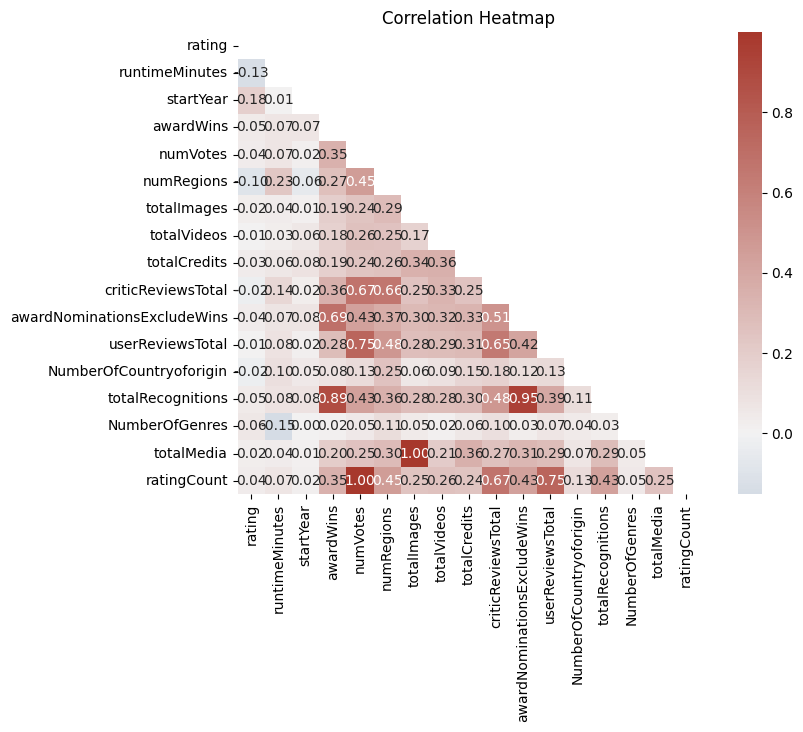


Top-10 Correlation Pairs:
                      Variable 1                   Variable 2  Correlation
84                      numVotes                  ratingCount     1.000000
261                   totalMedia                  totalImages     0.999188
231            totalRecognitions  awardNominationsExcludeWins     0.947469
224            totalRecognitions                    awardWins     0.886863
203             userReviewsTotal                  ratingCount     0.752152
191             userReviewsTotal                     numVotes     0.752104
173  awardNominationsExcludeWins                    awardWins     0.692494
169           criticReviewsTotal                  ratingCount     0.673640
77                      numVotes           criticReviewsTotal     0.673603
158           criticReviewsTotal                   numRegions     0.658817

Bottom-10 Correlation Pairs:
           Variable 1      Variable 2  Correlation
274       ratingCount       startYear     0.019102
70           num

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def analyze_correlation(data, columns, show_plot=True, top_n=10):
    """
    Analyze the correlation matrix for a subset of columns, optionally visualize a heatmap, 
    and return the top-N and bottom-N correlation pairs.
    
    Args:
        data (pd.DataFrame): The input DataFrame.
        columns (list): List of column names to include in the correlation analysis.
        show_plot (bool): Whether to display the heatmap. Default is True.
        top_n (int): Number of top and bottom correlation pairs to return. Default is 10.
    
    Returns:
        tuple: Two DataFrames containing the top-N and bottom-N correlation pairs.
    """
    # Filter the DataFrame to include only the desired subset of columns
    subset_data = data[columns]
    
    # Compute the correlation matrix for the subset
    corr_matrix = subset_data.corr()

    if show_plot:
        # Create a mask for the upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # Create a custom diverging palette
        cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)

        # Plot the heatmap
        plt.figure(figsize=(10, 6))
        sns.heatmap(corr_matrix, mask=mask, center=0, annot=True, fmt='.2f', square=True, cmap=cmap)
        plt.title("Correlation Heatmap")
        plt.show()

    # Flatten the correlation matrix and reset the index to get all pairs
    corr_pairs = corr_matrix.abs().unstack().reset_index()

    # Rename the columns for better understanding
    corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

    # Remove self-correlations (correlation of a variable with itself)
    corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]

    # Sort by correlation value in descending order
    sorted_corr_pairs = corr_pairs.sort_values(by='Correlation', ascending=False)

    # Drop duplicate pairs (e.g., A-B and B-A)
    sorted_corr_pairs = sorted_corr_pairs.drop_duplicates(subset=['Correlation'])

    # Get the top-N and bottom-N correlation pairs
    top_corr_pairs = sorted_corr_pairs.head(top_n)
    bottom_corr_pairs = sorted_corr_pairs.tail(top_n)

    return top_corr_pairs, bottom_corr_pairs

# Specify the subset of columns for which you want the correlation matrix
subset_columns = [
    "rating",
    "runtimeMinutes", 
    "startYear",
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "totalRecognitions", 
    "NumberOfGenres",
    "totalMedia",
    "ratingCount"
]

# Analyze the correlation matrix for the specified columns
top_corr_pairs, bottom_corr_pairs = analyze_correlation(data_train, subset_columns)

# Print the top-10 and bottom-10 correlation pairs
print("\nTop-10 Correlation Pairs:")
print(top_corr_pairs)

print("\nBottom-10 Correlation Pairs:")
print(bottom_corr_pairs)

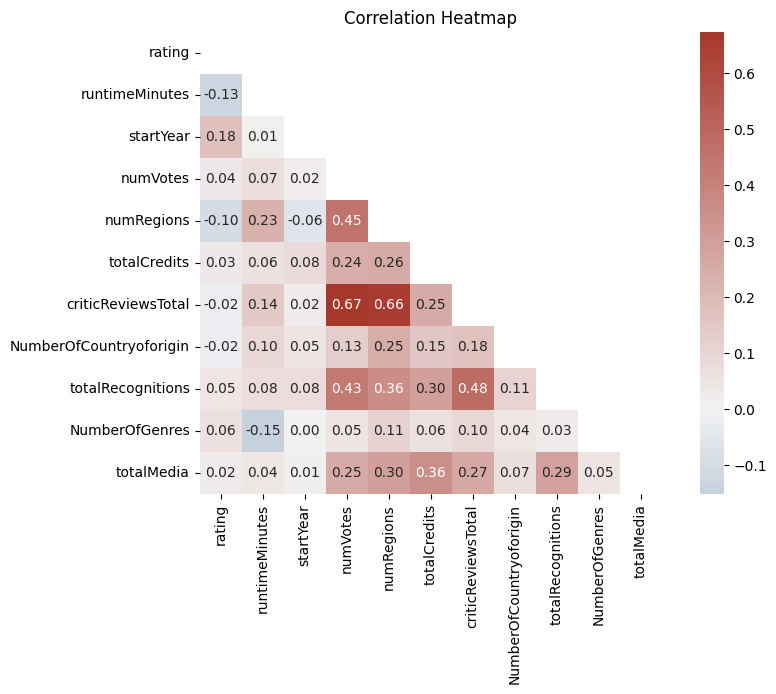

In [6]:
data_train = data_train.drop(columns='ratingCount')
data_test = data_test.drop(columns='ratingCount')

data_train = data_train.drop(columns='totalImages')
data_test = data_test.drop(columns='totalImages')

data_train = data_train.drop(columns='totalVideos')
data_test = data_test.drop(columns='totalVideos')

data_train = data_train.drop(columns='awardNominationsExcludeWins')
data_test = data_test.drop(columns='awardNominationsExcludeWins')

data_train = data_train.drop(columns='awardWins')
data_test = data_test.drop(columns='awardWins')

data_train = data_train.drop(columns='userReviewsTotal')
data_test = data_test.drop(columns='userReviewsTotal')

subset_columns = [
    "rating",
    "runtimeMinutes",
    "startYear", 
    "numVotes", 
    "numRegions", 
    "totalCredits", 
    "criticReviewsTotal", 
    "NumberOfCountryoforigin", 
    "totalRecognitions", 
    "NumberOfGenres",
    "totalMedia",
]


top_corr_pairs, bottom_corr_pairs = analyze_correlation(data_train, subset_columns)



# Standardization
First of all we plot the distribution of all numerical columns

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis

def plot_column_distribution(dataframe, column_name, bins=30):
    """
    Plots the distribution of a specific column in a dataset, 
    along with log-transformed and square root-transformed distributions.

    Args:
        dataframe (pd.DataFrame): The dataset containing the column.
        column_name (str): The name of the column to plot.
        bins (int): Number of bins for the histogram (default 30).
    """
    if column_name not in dataframe.columns:
        raise ValueError(f"The column '{column_name}' does not exist in the dataset.")

    # Validate the data
    column_data = dataframe[column_name].dropna()

    # Compute skewness and kurtosis for each transformation
    original_skewness = skew(column_data)
    original_kurtosis = kurtosis(column_data)  # Excess kurtosis (subtracts 3 automatically)

    log_transformed = np.log1p(column_data)
    log_skewness = skew(log_transformed)
    log_kurtosis = kurtosis(log_transformed)

    sqrt_transformed = np.sqrt(column_data)
    sqrt_skewness = skew(sqrt_transformed)
    sqrt_kurtosis = kurtosis(sqrt_transformed)

    # Create subplots
    fig, axes = plt.subplots(3, 1, figsize=(10, 18))
    
    # Original distribution
    sns.histplot(column_data, bins=bins, kde=True, color='blue', alpha=0.6, ax=axes[0])
    axes[0].set_title(f'Original Distribution: {column_name} (Skewness: {original_skewness:.2f}, Kurtosis: {original_kurtosis:.2f})', fontsize=16)
    axes[0].set_xlabel(column_name, fontsize=14)
    axes[0].set_ylabel('Frequency', fontsize=14)
    axes[0].grid(True, alpha=0.3)

    # Log-transformed distribution
    sns.histplot(log_transformed, bins=bins, kde=True, color='green', alpha=0.6, ax=axes[1])
    axes[1].set_title(f'Log-Transformed Distribution: log({column_name} + 1) (Skewness: {log_skewness:.2f}, Kurtosis: {log_kurtosis:.2f})', fontsize=16)
    axes[1].set_xlabel(f'log({column_name} + 1)', fontsize=14)
    axes[1].set_ylabel('Frequency', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    # Square root-transformed distribution
    sns.histplot(sqrt_transformed, bins=bins, kde=True, color='orange', alpha=0.6, ax=axes[2])
    axes[2].set_title(f'Square Root Transformed Distribution: sqrt({column_name}) (Skewness: {sqrt_skewness:.2f}, Kurtosis: {sqrt_kurtosis:.2f})', fontsize=16)
    axes[2].set_xlabel(f'sqrt({column_name})', fontsize=14)
    axes[2].set_ylabel('Frequency', fontsize=14)
    axes[2].grid(True, alpha=0.3)

    # Adjust layout
    plt.tight_layout()
    plt.show()

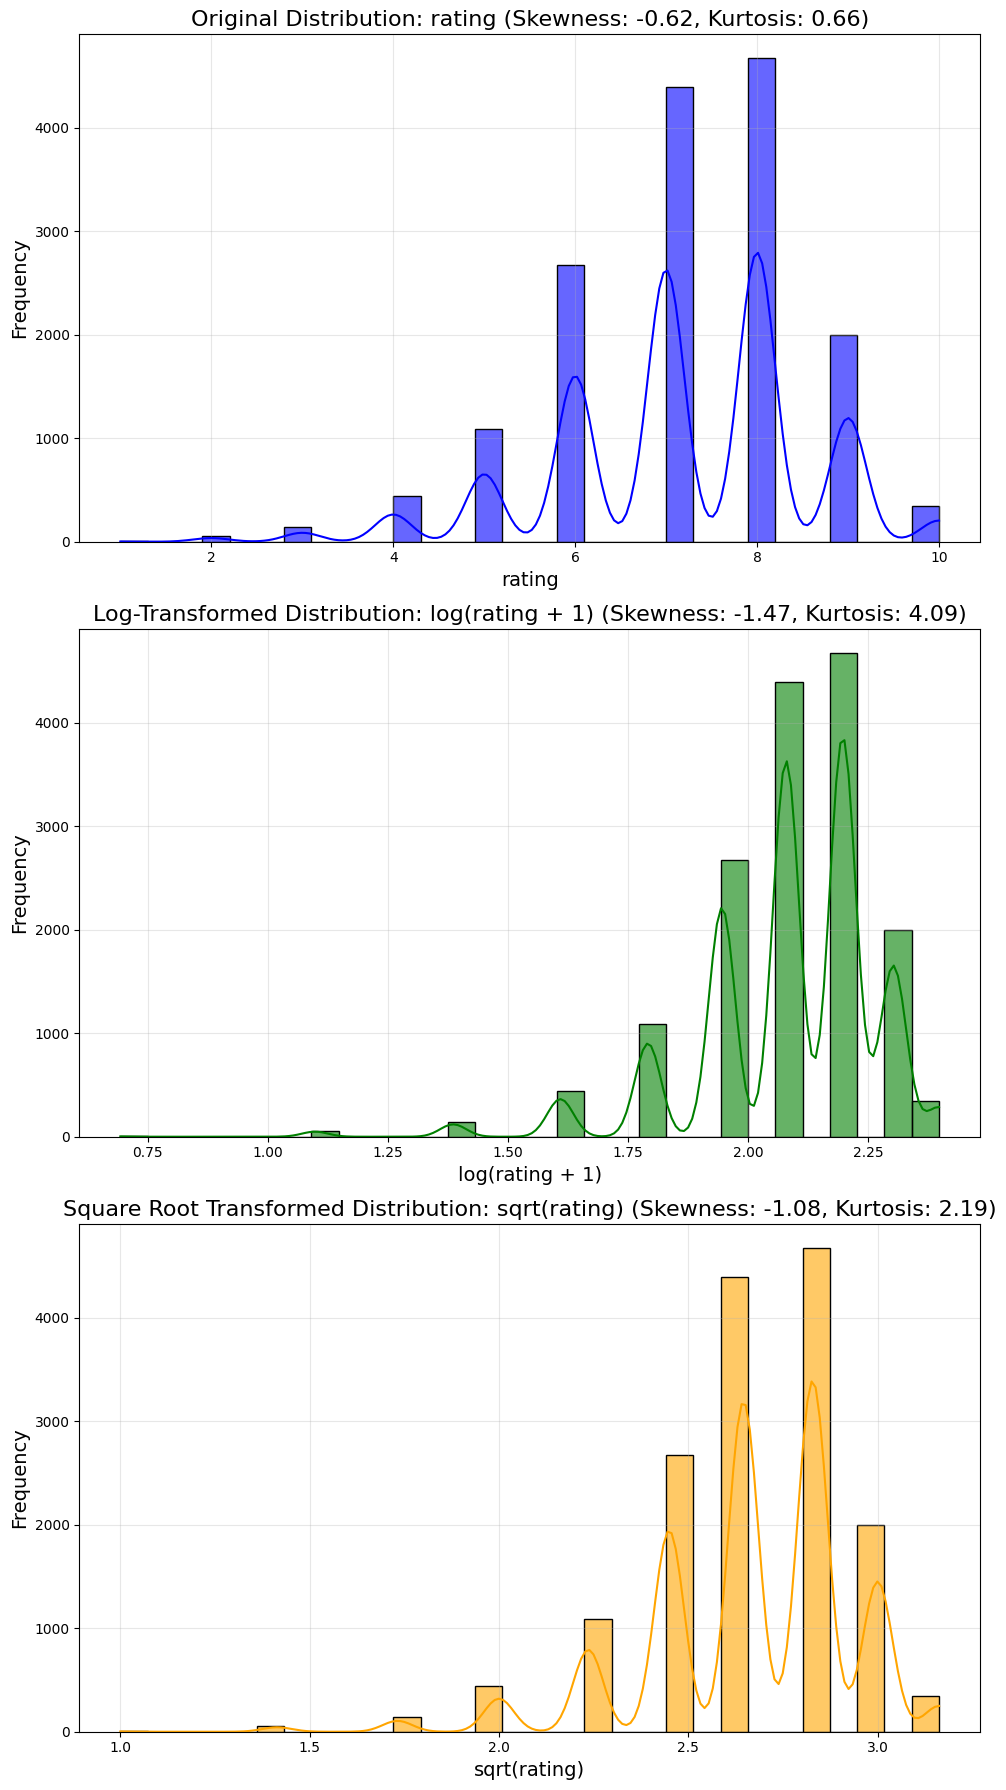

In [8]:
plot_column_distribution(data_train, 'rating')

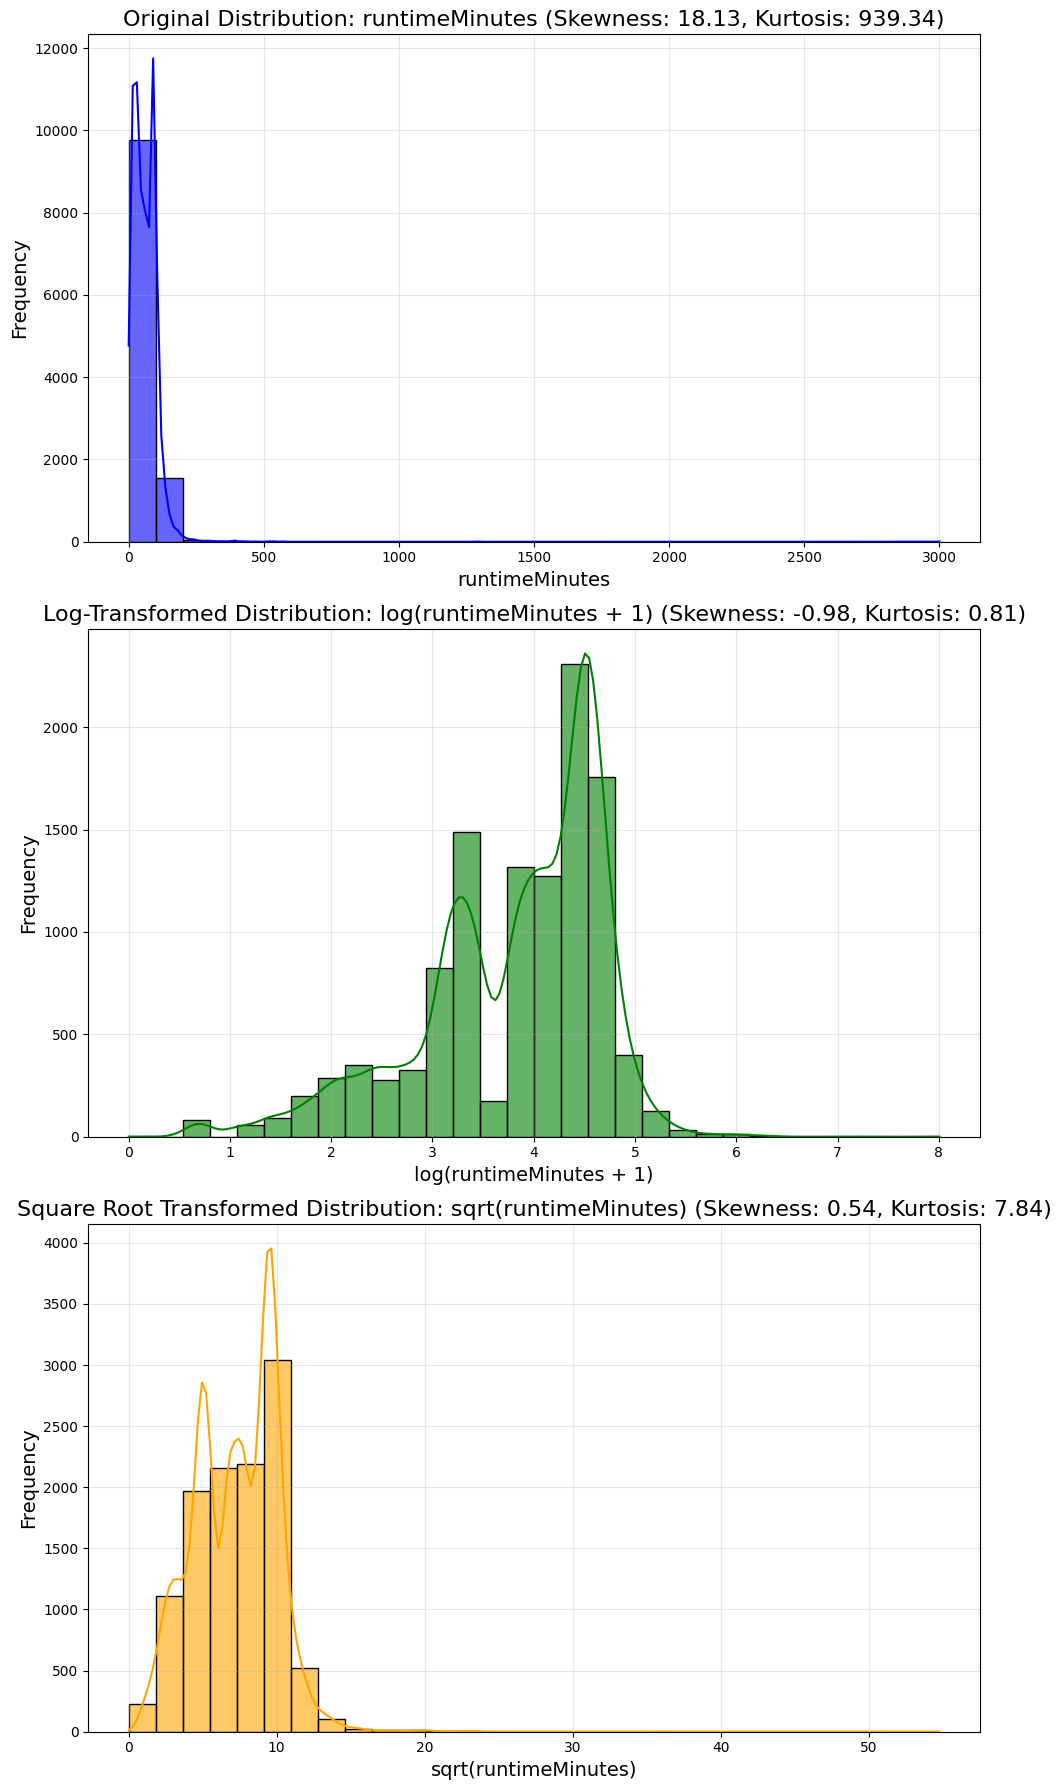

In [9]:
plot_column_distribution(data_train, 'runtimeMinutes')


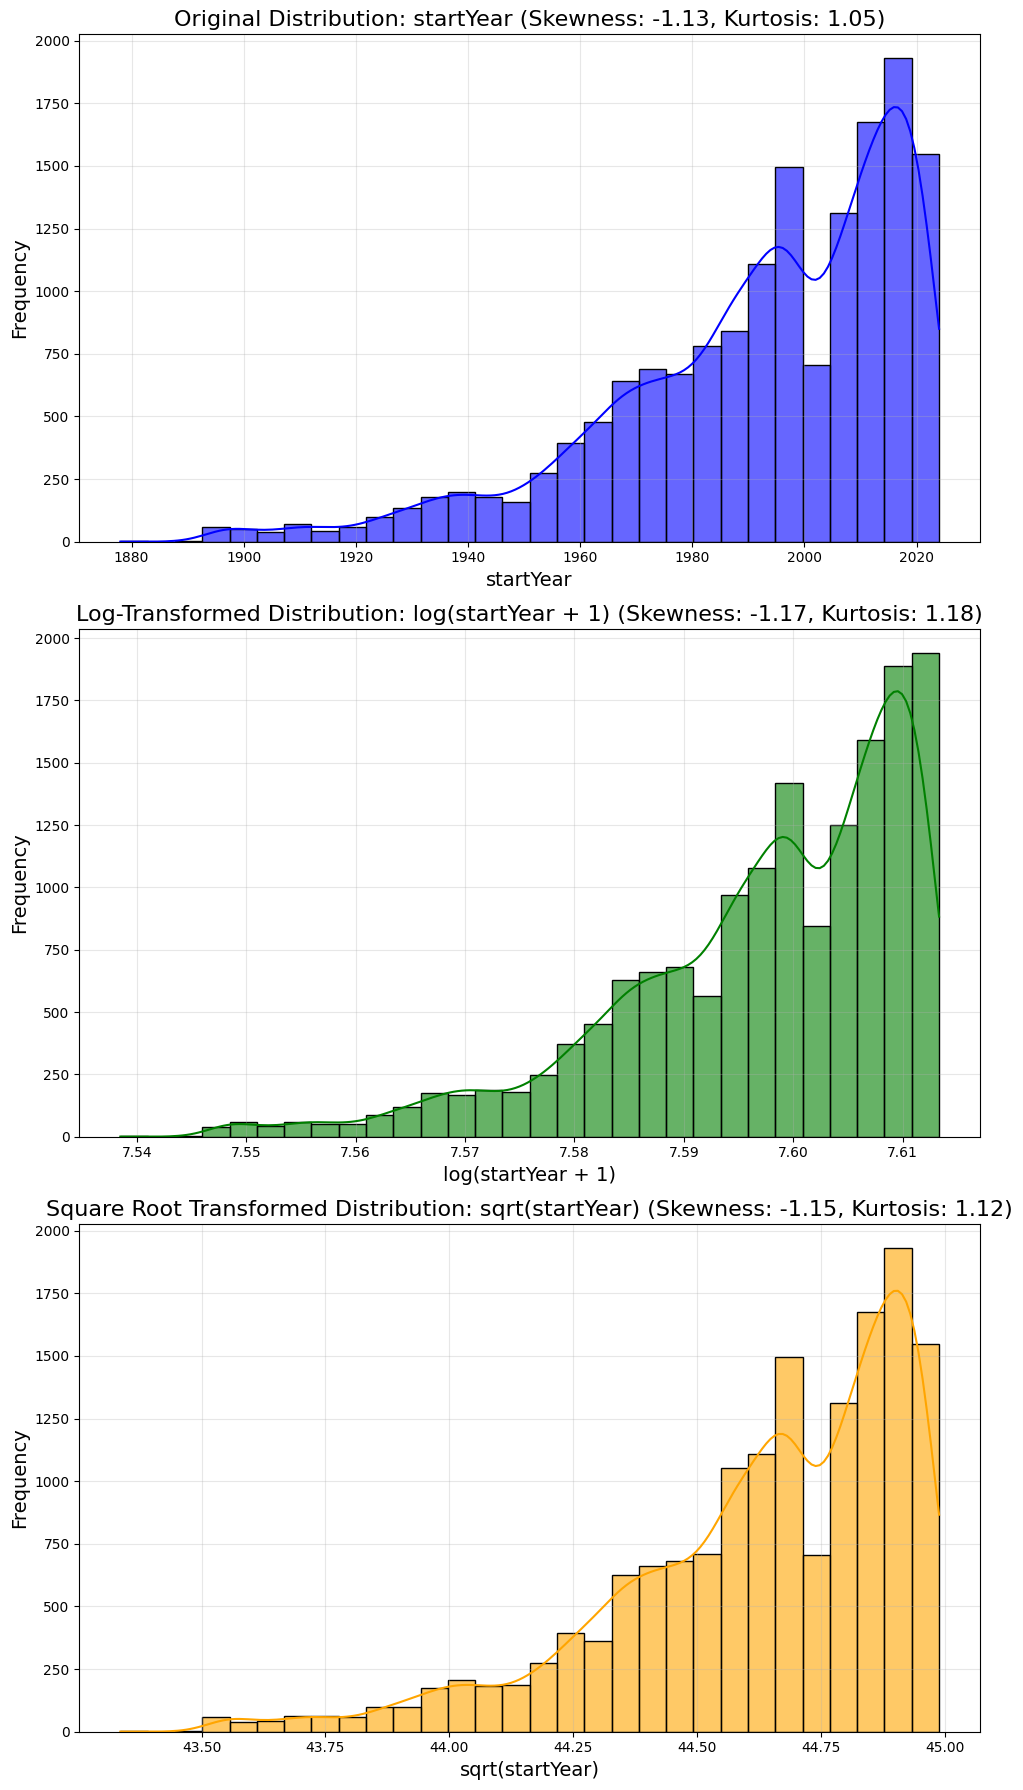

In [10]:
plot_column_distribution(data_train, 'startYear')

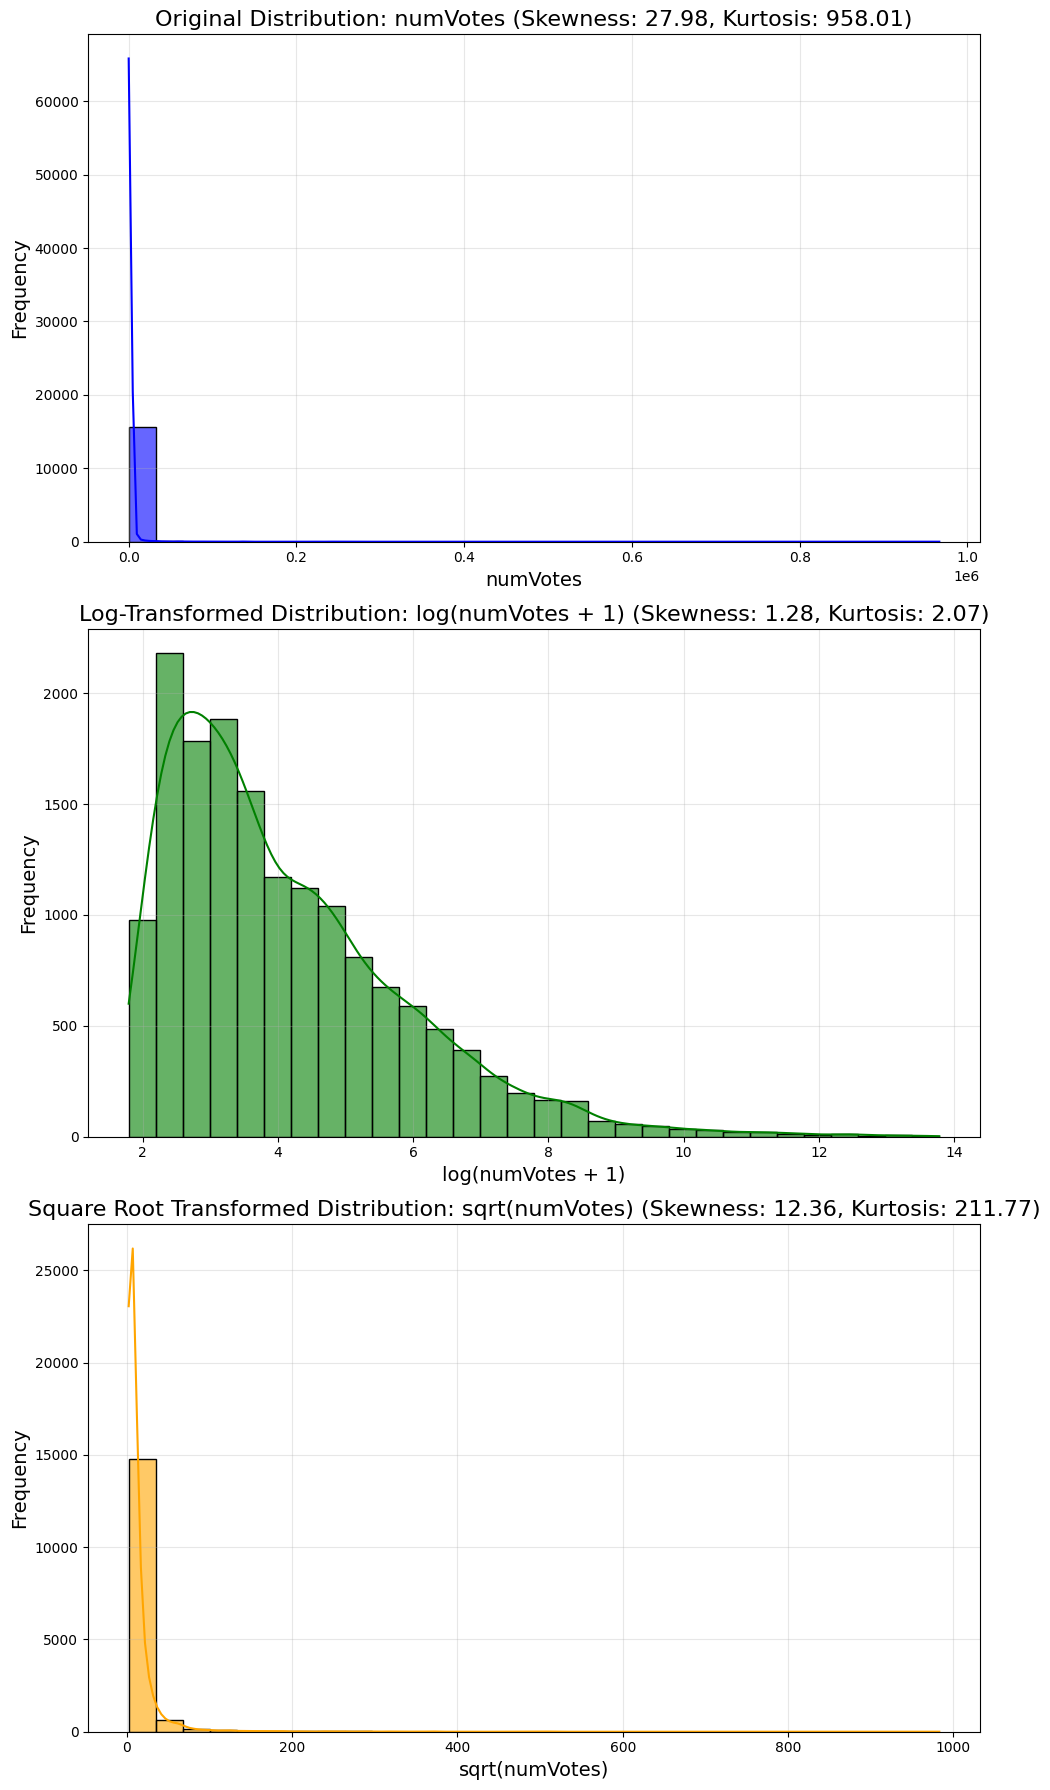

In [11]:
plot_column_distribution(data_train, 'numVotes')

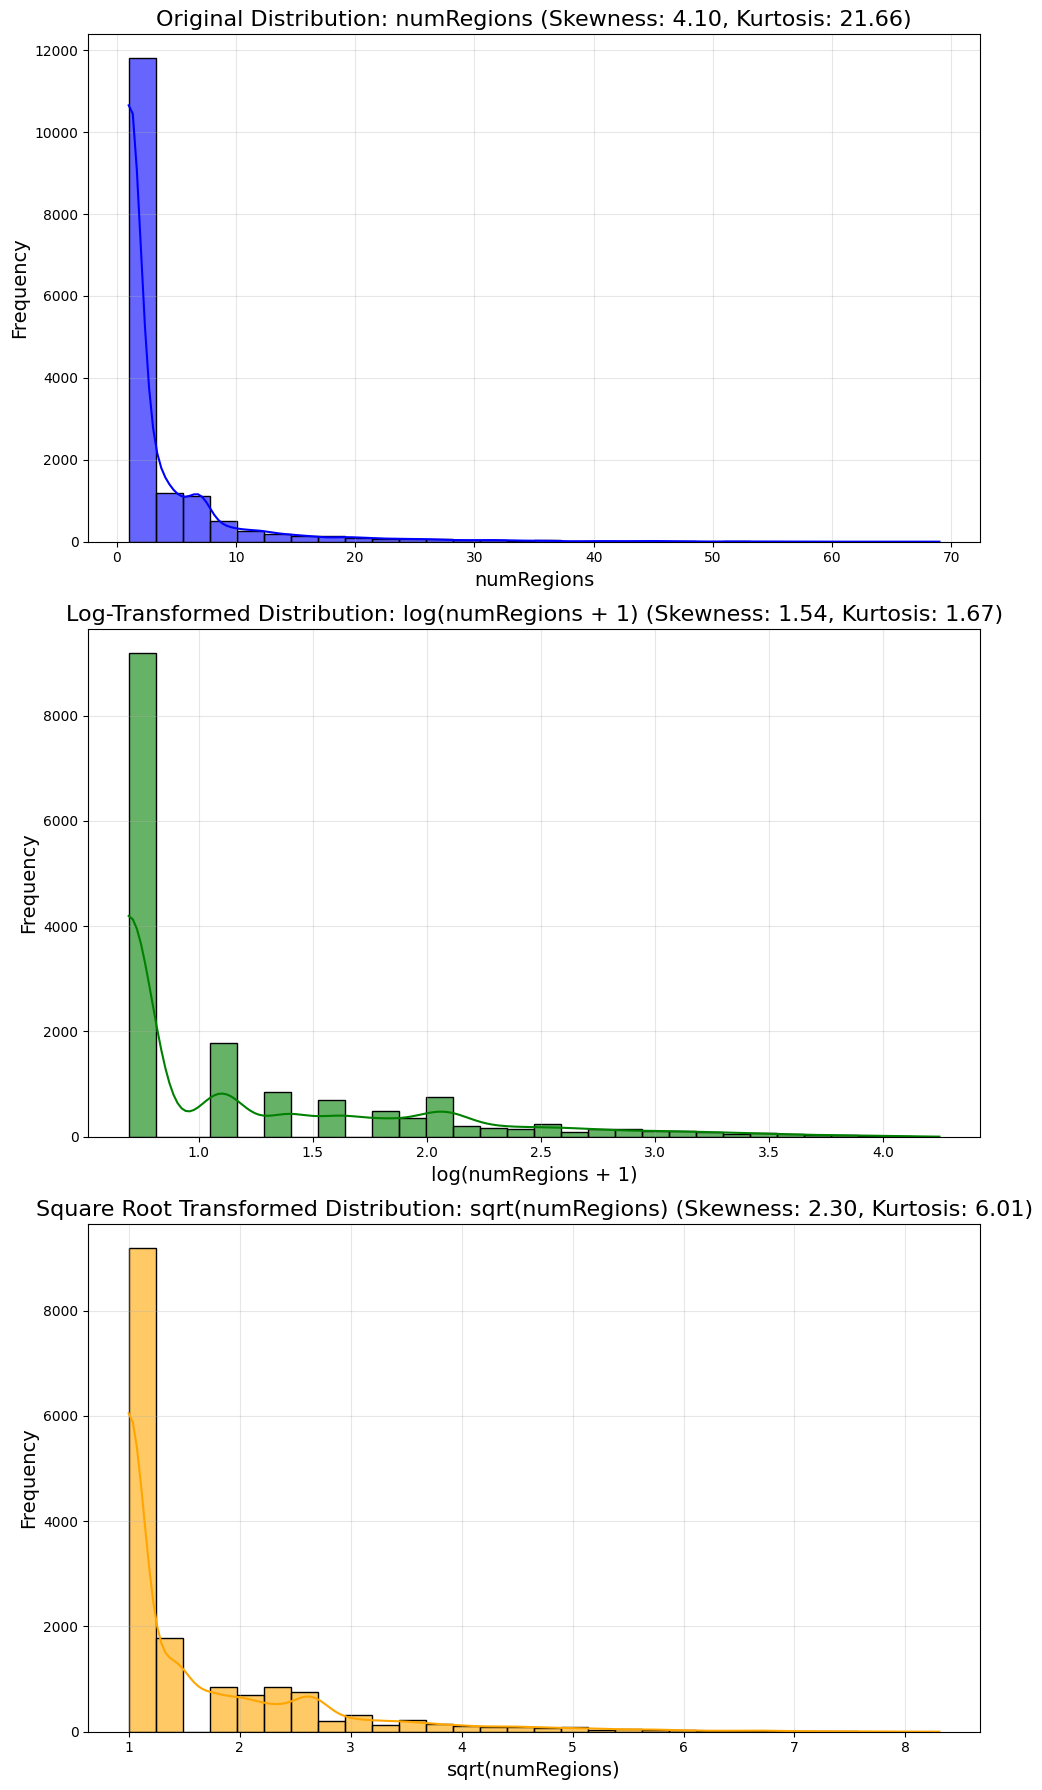

In [12]:
plot_column_distribution(data_train, 'numRegions')

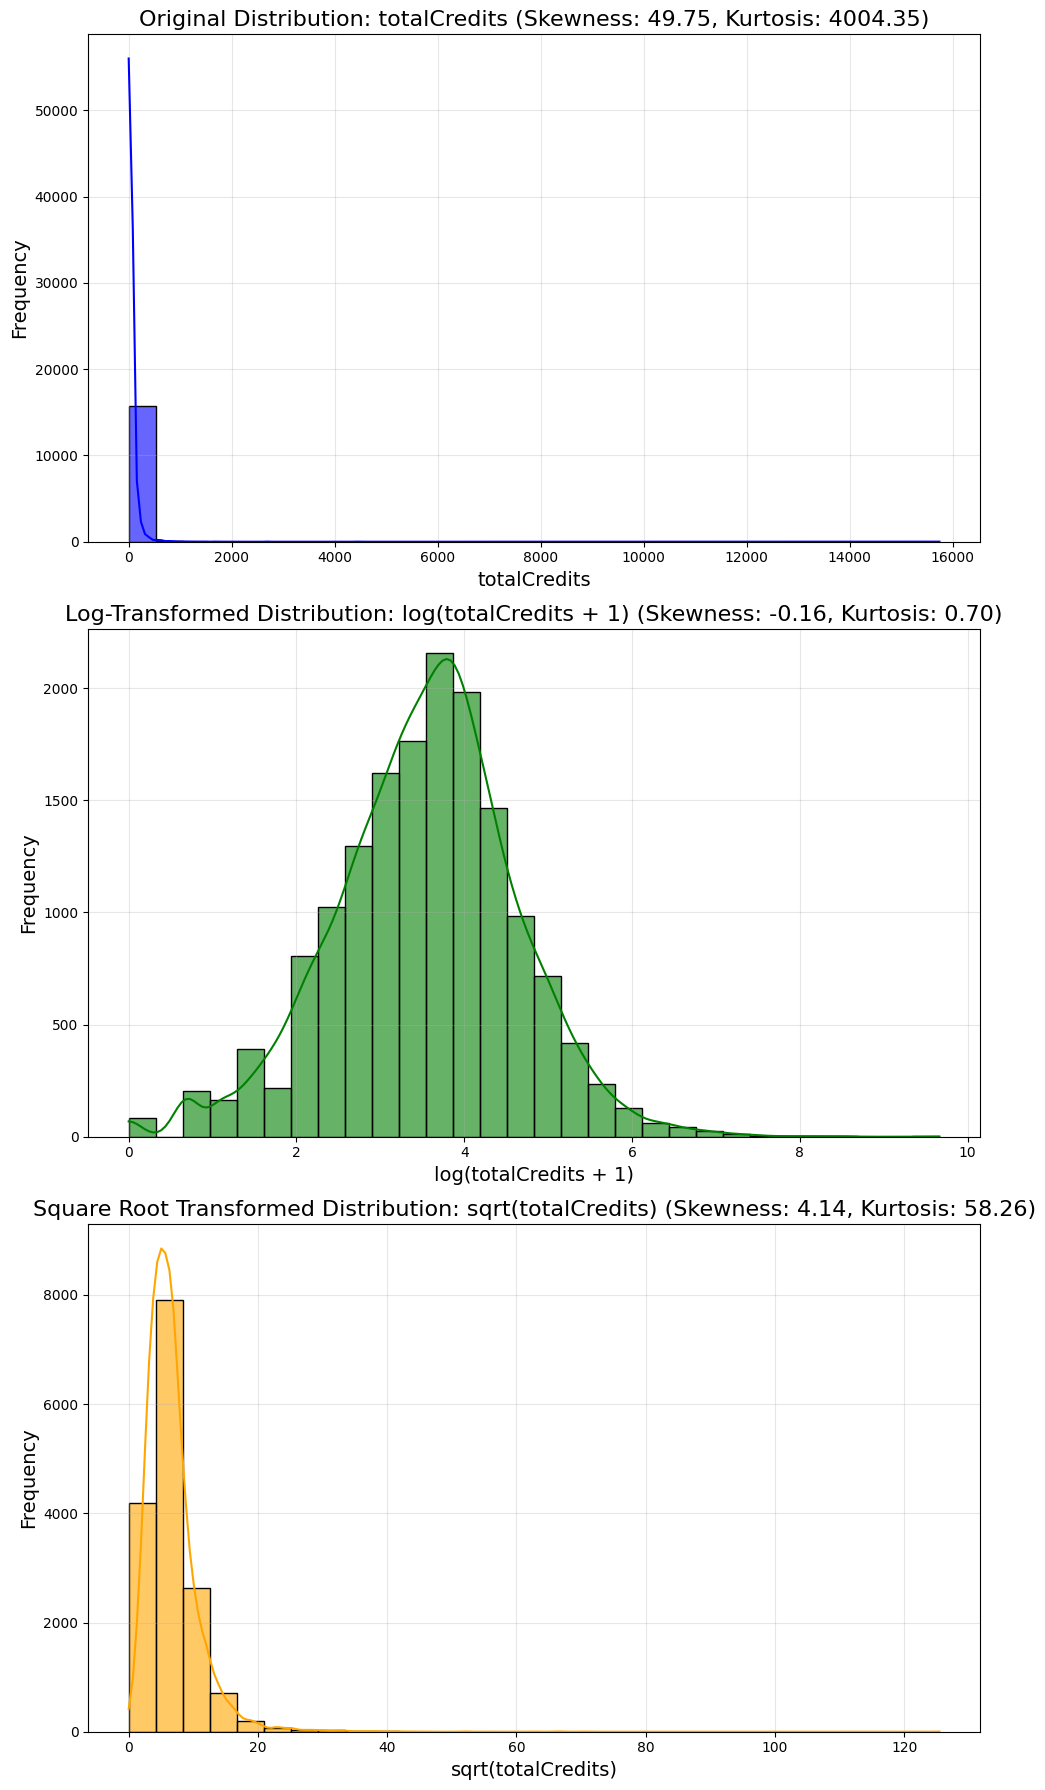

In [13]:
plot_column_distribution(data_train, 'totalCredits')

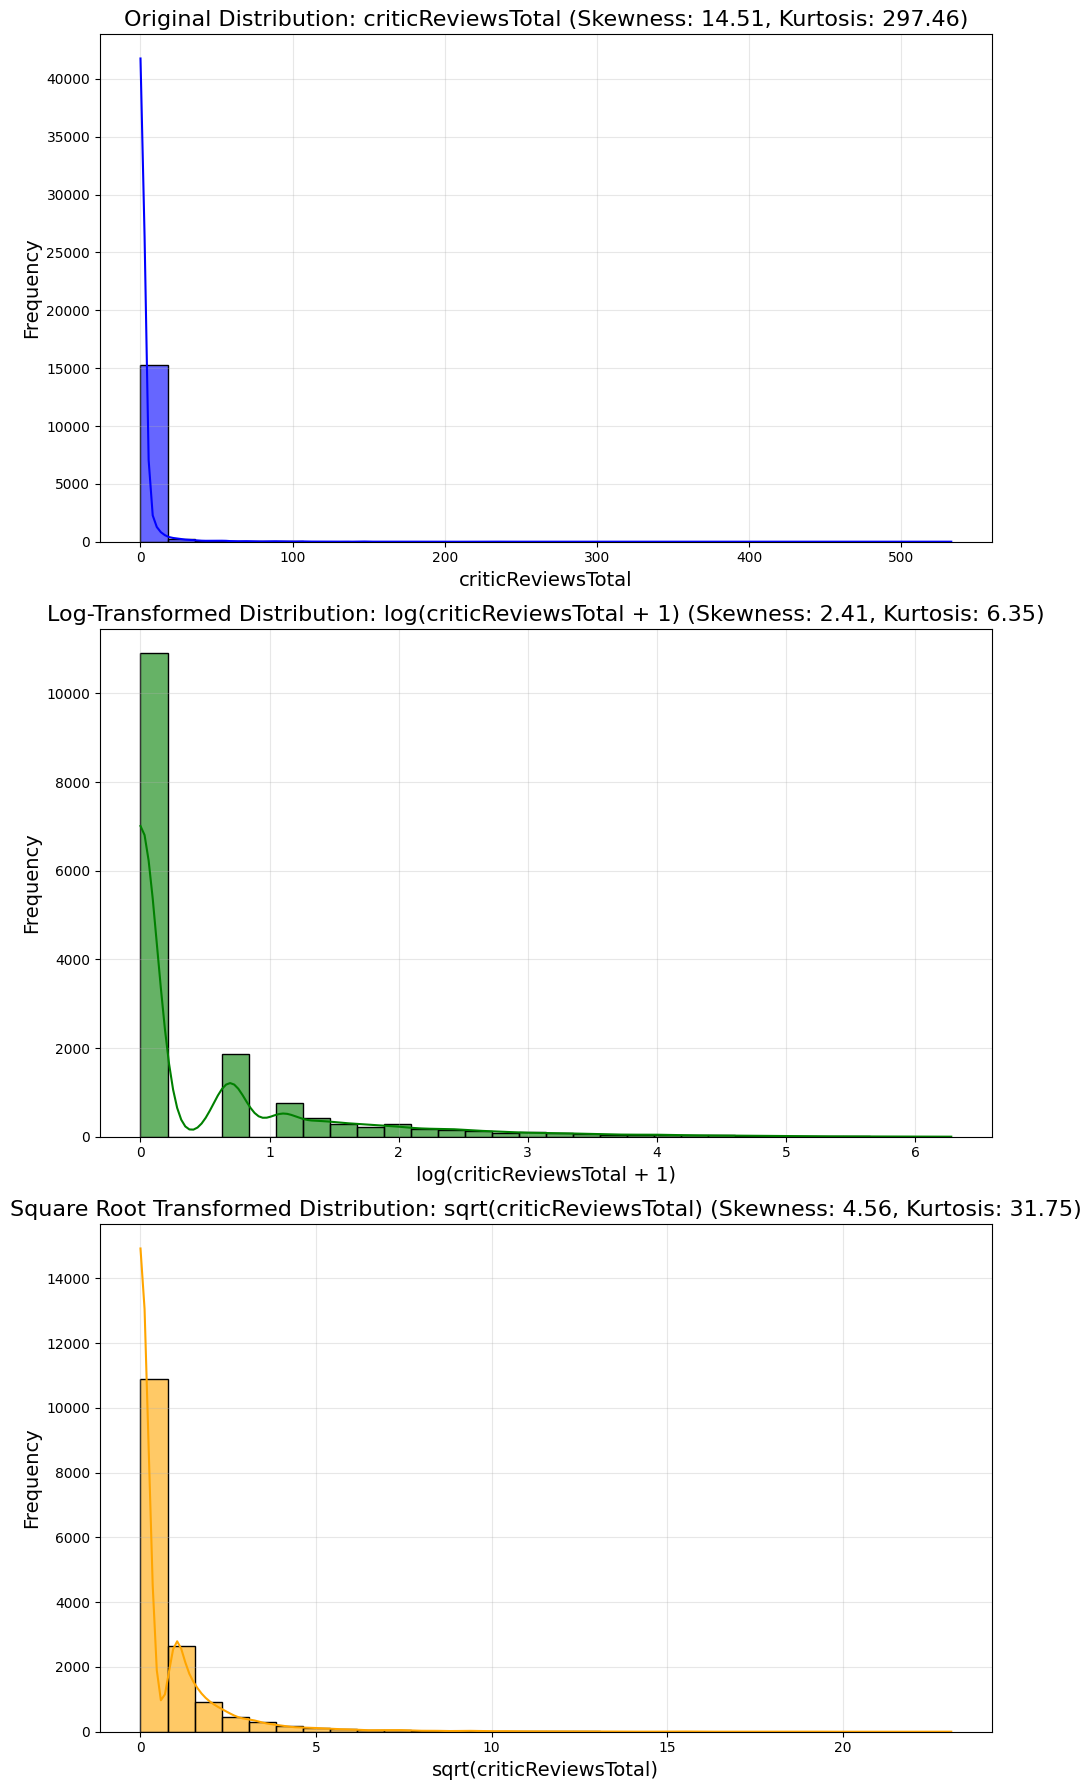

In [14]:
plot_column_distribution(data_train, 'criticReviewsTotal')

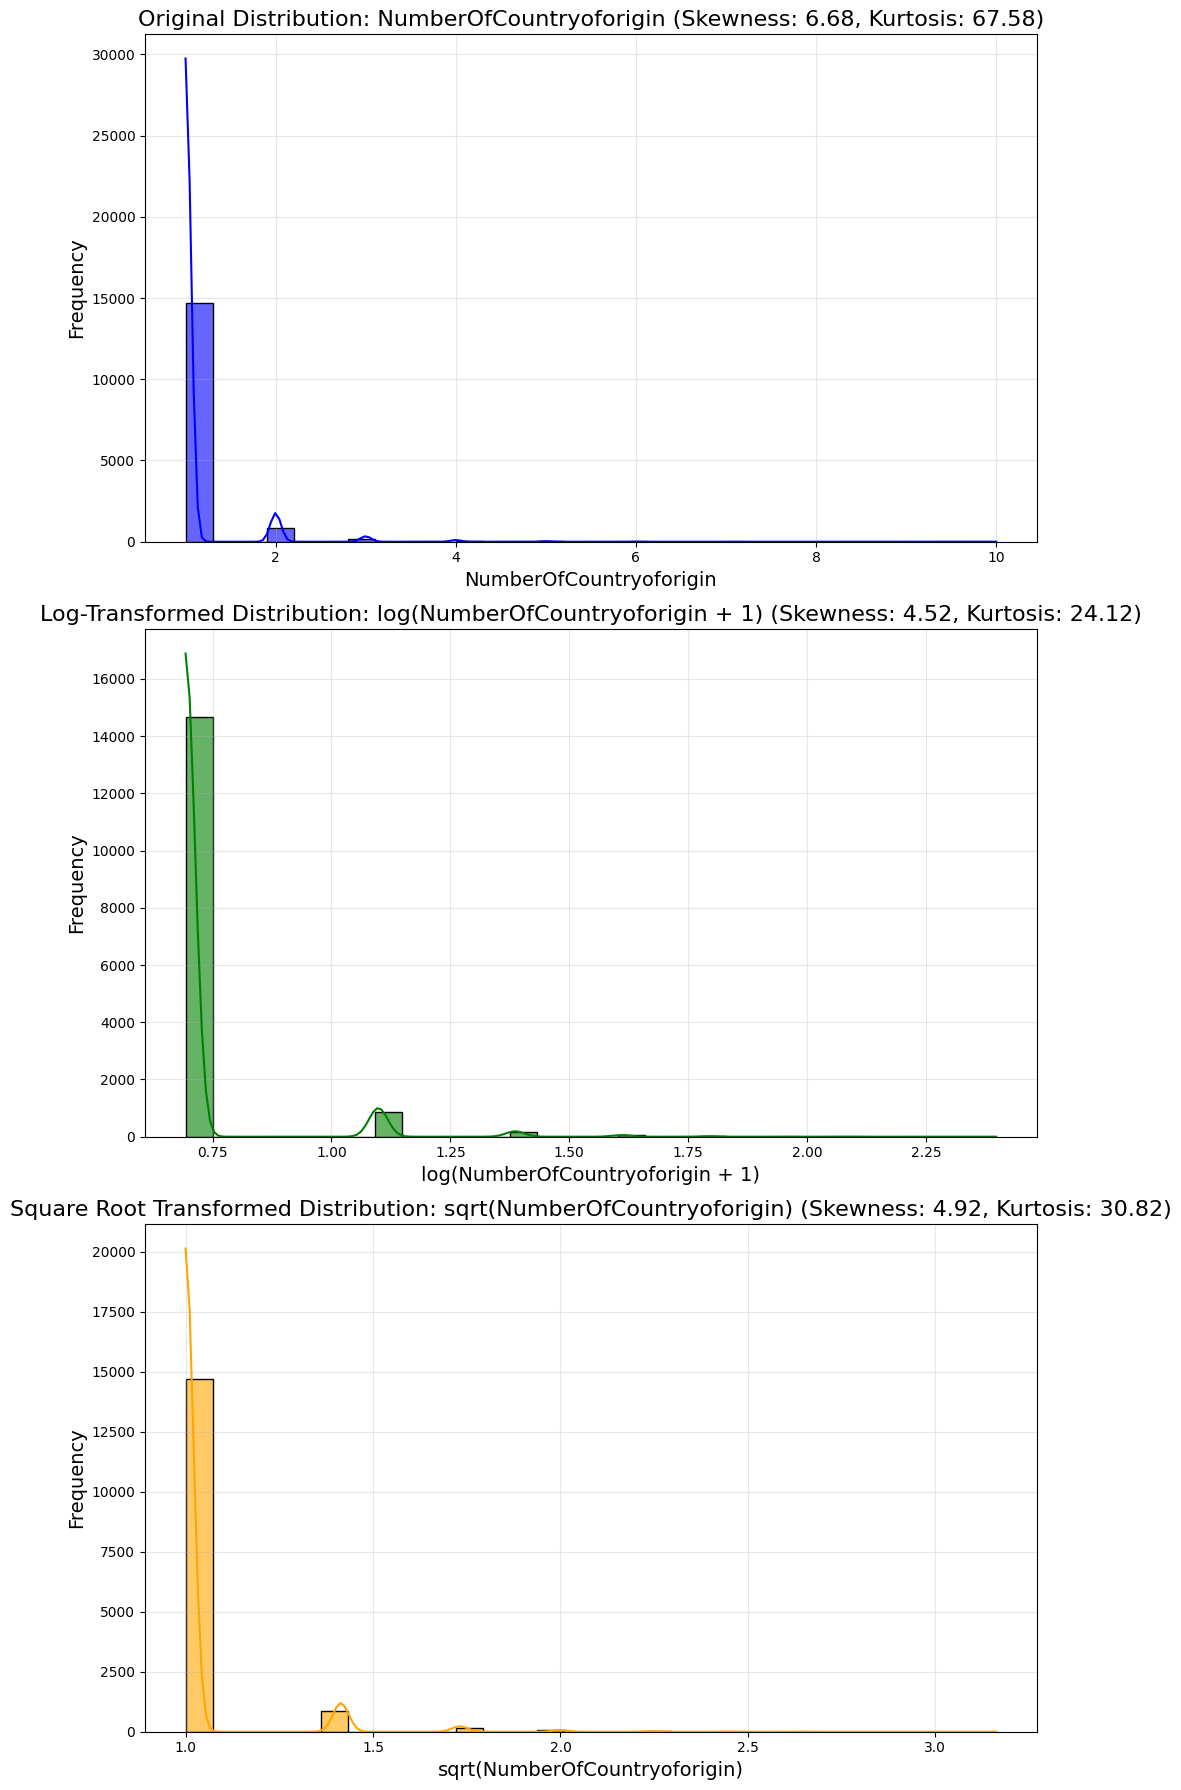

In [15]:
plot_column_distribution(data_train, 'NumberOfCountryoforigin')

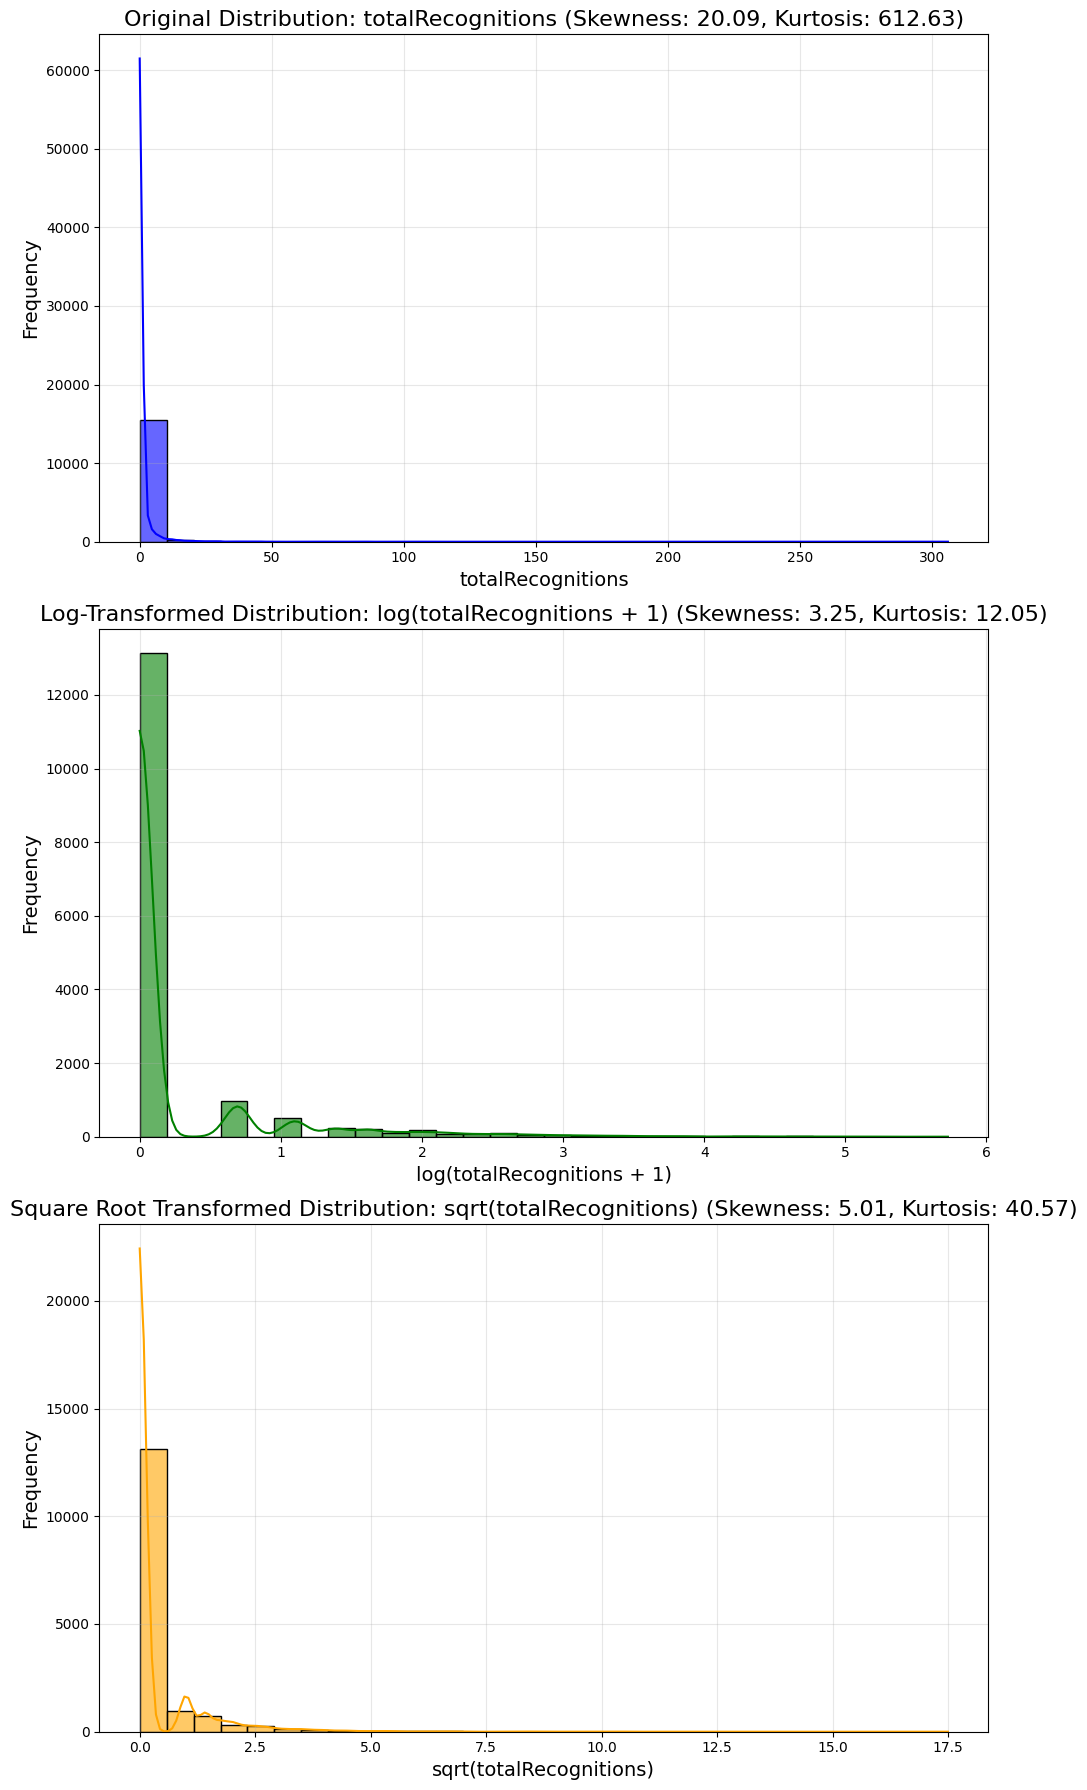

In [16]:
plot_column_distribution(data_train, 'totalRecognitions')

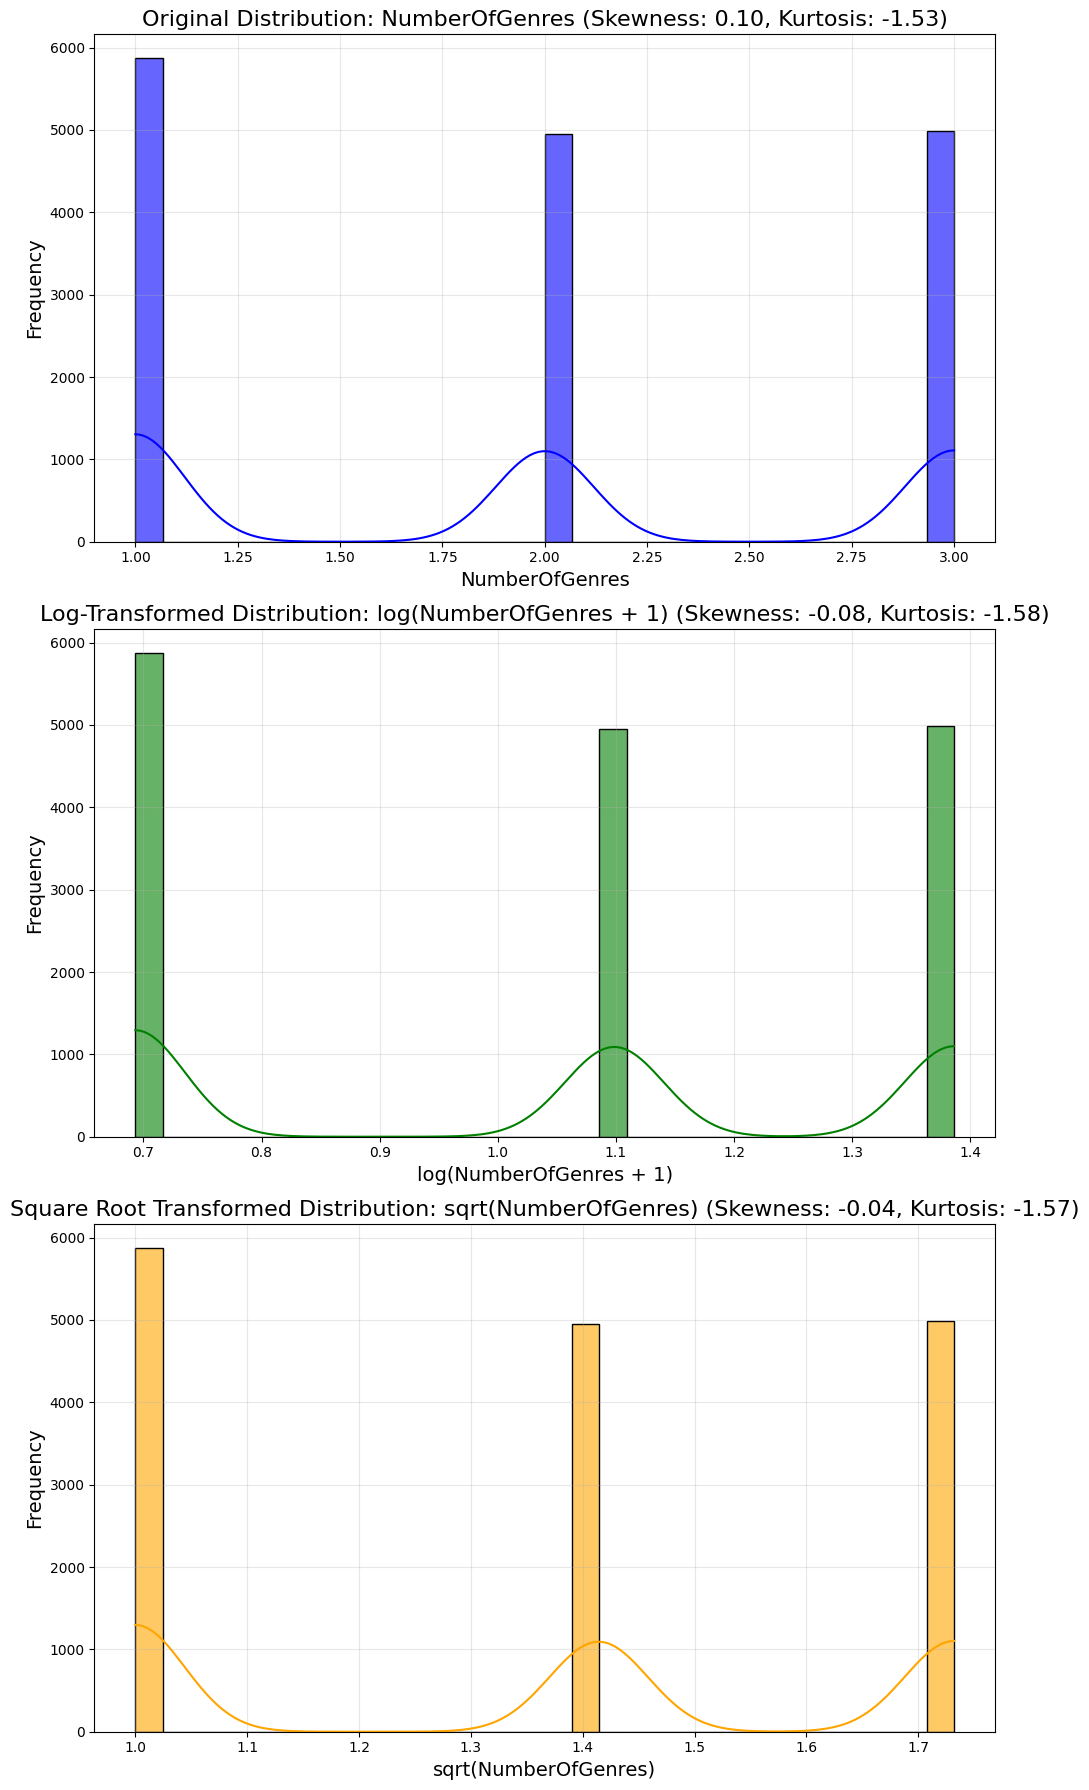

In [17]:
plot_column_distribution(data_train, 'NumberOfGenres')

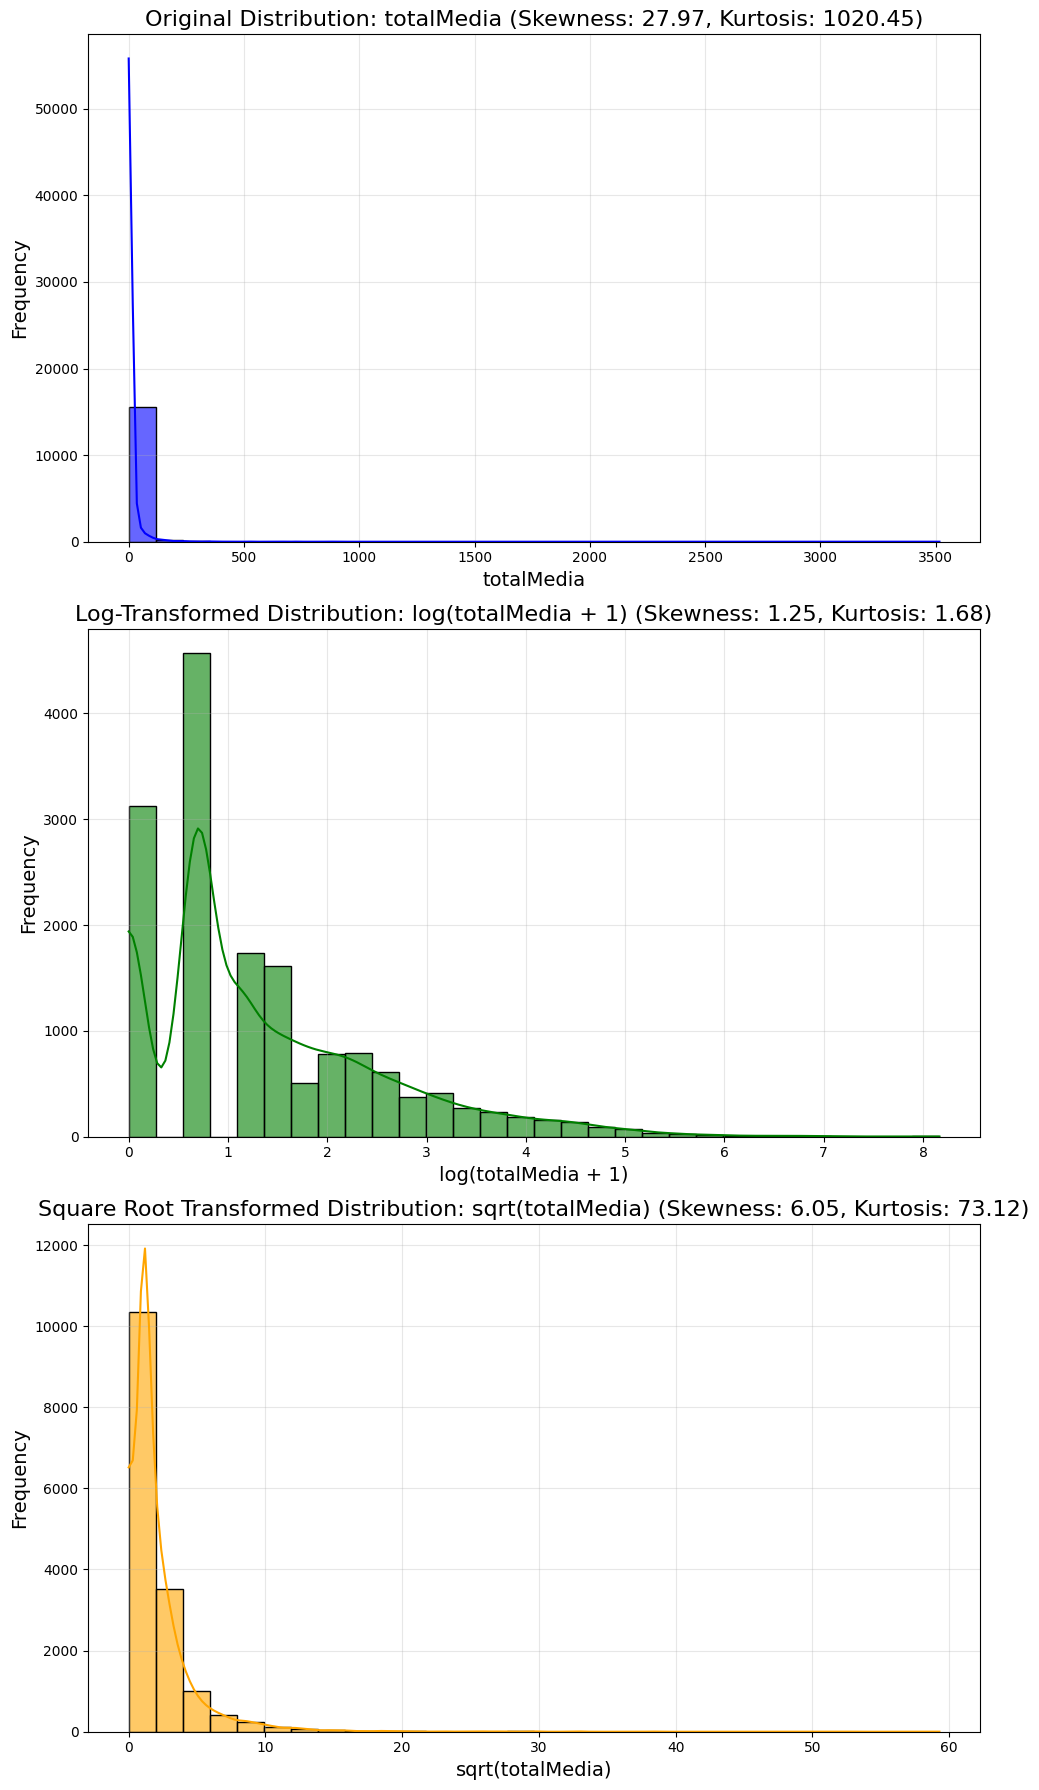

In [18]:
plot_column_distribution(data_train, 'totalMedia')

# Distribution analysis
- `rating` perfect
- `runtimeMinutes`: **sqrt** sembra lasciare degli outlier e la skewness ottima con l'individuazione degli outlier porterà a un miglioramento della kurtosis
- `startYear`: non cambia con nessuna scala, invariato
- `numVotes` **log** strongly improves skewness and kurtosis
- `numRegions`: **log** migliora skewness e kurtosis
- `totalCredits`: **log** la rende una guassiana quasi perfetta
- `criticReviewsTotal`: **log**favorisce l'identificazione di outlier
- `NumberOfCountryOfOrigin`: invariato
- `nominations`: **log** migliora entrambi gliindicatori
- `numberOfGenres`: invariato
- `totalMedia`: **log**


Per runTimeMinutes e totalCredits eliminare code destra e sinistra

Non si tocca `rating`, `startYear`, `numberOfGenres`, `NumberOfCountryOfOrigin`.

Per `numVotes`, `numRegions`, `criticReviewsTotal`, `nominations` e `totalMedia` si elimina la coda a destra eliminando gli zeri.

Terminare con min-max scaling [0-10] per allinearsi a rating


In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def transform_data(df):
    """
    Trasforma le colonne di un DataFrame secondo le regole definite.

    Args:
        df (pd.DataFrame): Il dataset originale.

    Returns:
        pd.DataFrame: Il dataset trasformato.
    """
    # Copia il DataFrame per evitare modifiche non volute
    transformed_df = df.copy()

    # Definizione delle trasformazioni
    transformations = {
        'runtimeMinutes': 'log',
        'numVotes': 'log',       
        'numRegions': 'log',     
        'totalCredits': 'log',    # Logaritmo
        'criticReviewsTotal': 'log',  # Logaritmo
        'totalRecognitions': 'sqrt',  # Logaritmo
        'totalMedia': 'log',  # Logaritmo
    }

    for column, transformation in transformations.items():
        if column in transformed_df.columns:
            # Gestione delle trasformazioni
            if transformation == 'log':
                transformed_df[column] = np.log1p(transformed_df[column])  # log(x+1)
            elif transformation == 'sqrt':
                transformed_df[column] = np.sqrt(transformed_df[column])
    return transformed_df

# Applica le trasformazioni al dataset di addestramento
scaled_train = transform_data(data_train)
# Applica le trasformazioni al dataset di test
scaled_test = transform_data(data_test)


In [20]:
def summarize_columns(dataframe, columns):
    """
    Prints the minimum, maximum, median, and average of the specified columns in the DataFrame.

    Parameters:
    dataframe (pd.DataFrame): The DataFrame containing the data.
    columns (list): List of column names to summarize.

    Returns:
    None
    """
    summary = []
    for column in columns:
        if column in dataframe.columns:
            col_data = dataframe[column]
            if pd.api.types.is_numeric_dtype(col_data):
                summary.append({
                    "Column": column,
                    "Min": col_data.min(),
                    "Max": col_data.max(),
                    "Median": col_data.median(),
                    "avg": col_data.mean(),
                    "Std Dev": col_data.std()
                })
            else:
                print(f"Skipping non-numeric column: {column}")
        else:
            print(f"Column '{column}' not found in the DataFrame.")
    print(pd.DataFrame(summary))

In [21]:
columns_to_scale = [
    "rating",
    "runtimeMinutes", 
    "numVotes",
    "numRegions",
    "totalCredits",
    "criticReviewsTotal",
    "totalRecognitions",
    "totalMedia"
]
summarize_columns(data_train, columns_to_scale)

               Column  Min       Max  Median          avg       Std Dev
0              rating  1.0      10.0     7.0     7.165865      1.382448
1      runtimeMinutes  0.0    3000.0    57.0    60.710524     51.828019
2            numVotes  5.0  966565.0    38.0  1544.254145  20530.675658
3          numRegions  1.0      69.0     1.0     3.619415      5.951703
4        totalCredits  0.0   15742.0    35.0    62.573535    177.087586
5  criticReviewsTotal  0.0     533.0     0.0     2.880142     15.699582
6   totalRecognitions  0.0     306.0     0.0     0.994621      6.269422
7          totalMedia  0.0    3516.0     2.0    12.012593     76.079570


In [22]:
summarize_columns(scaled_train, columns_to_scale)

               Column       Min        Max    Median       avg   Std Dev
0              rating  1.000000  10.000000  7.000000  7.165865  1.382448
1      runtimeMinutes  0.000000   8.006701  4.060443  3.813592  0.894782
2            numVotes  1.791759  13.781505  3.663562  4.109710  1.769287
3          numRegions  0.693147   4.248495  0.693147  1.170147  0.715801
4        totalCredits  0.000000   9.664151  3.583519  3.530540  1.094218
5  criticReviewsTotal  0.000000   6.280396  0.000000  0.470711  0.898103
6   totalRecognitions  0.000000  17.492856  0.000000  0.329713  0.941258
7          totalMedia  0.000000   8.165364  1.098612  1.331966  1.209216


In [23]:
summarize_columns(data_test, columns_to_scale)

               Column  Min        Max  Median          avg       Std Dev
0              rating  1.0       10.0     7.0     7.158944      1.382427
1      runtimeMinutes  1.0     1050.0    60.0    62.548062     46.849902
2            numVotes  5.0  1071372.0    39.0  1578.248576  23026.328457
3          numRegions  1.0       63.0     1.0     3.665970      5.951489
4        totalCredits  0.0     2482.0    36.0    61.407710    111.369547
5  criticReviewsTotal  0.0      567.0     0.0     3.216293     18.827354
6   totalRecognitions  0.0      409.0     0.0     0.991075      8.273605
7          totalMedia  0.0     2526.0     2.0    11.211546     59.004358


In [24]:
summarize_columns(scaled_test, columns_to_scale)

               Column       Min        Max    Median       avg   Std Dev
0              rating  1.000000  10.000000  7.000000  7.158944  1.382427
1      runtimeMinutes  0.693147   6.957497  4.110874  3.856125  0.872887
2            numVotes  1.791759  13.884452  3.688879  4.112440  1.762570
3          numRegions  0.693147   4.158883  0.693147  1.179841  0.719359
4        totalCredits  0.000000   7.817223  3.610918  3.550365  1.072421
5  criticReviewsTotal  0.000000   6.342121  0.000000  0.480140  0.918788
6   totalRecognitions  0.000000  20.223748  0.000000  0.325465  0.940912
7          totalMedia  0.000000   7.834788  1.098612  1.354075  1.214998


# Outlier detection

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_and_store_outliers_union(data1, data2, column, group_by, iqr_multipliers, output_path, show_plot=False, detect_lower_outliers=True):
    """
    Calculate and visualize outliers for a numeric column grouped by another column
    using the union of two datasets. Save a summary table with the number of outliers 
    for each group and IQR multiplier as a column to a CSV file, including the percentage 
    of theoretical elimination for each dataset.

    Args:
        data1 (pd.DataFrame): The first input dataset.
        data2 (pd.DataFrame): The second input dataset.
        column (str): The numeric column to analyze for outliers.
        group_by (str): The column to group b    "numRegions", "totalVideos", "NumberOfCountryoforigin", "NumberOfGenres",
    "awardWins", "numVotes", "totalImages", "totalCredits",
    "awardNominationsExcludeWins", "userReviewsTotal", "totalRecognitions"
]
y.    "numRegions", "totalVideos", "NumberOfCountryoforigin", "NumberOfGenres",
    "awardWins", "numVotes", "totalImages", "totalCredits",
    "awardNominationsExcludeWins", "userReviewsTotal", "totalRecognitions"
]

        iqr_multipliers (list of float): A list of multipliers for the IQR to define outlier boundaries.
        output_path (str): The path to save the summary CSV file.
        show_plot (bool, optional): Whether to calculate and display plots. Default is False.
        detect_lower_outliers (bool, optional): Whether to detect lower outliers. Default is True.
    """
    # Combine the datasets
    combined_data = pd.concat([data1, data2], ignore_index=True)

    if column not in combined_data.columns:
        raise ValueError(f"Column '{column}' not found in the datasets.")

    if group_by not in combined_data.columns:
        raise ValueError(f"Group-by column '{group_by}' not found in the datasets.")

    grouped = combined_data.groupby(group_by)
    summary = []

    # Calculate and store outliers for each group and IQR multiplier
    for group_name, group_data in grouped:
        group_summary = {"Group": group_name}

        for iqr_multiplier in iqr_multipliers:
            # Exclude null values for outlier calculations
            group_data_non_null = group_data[group_data[column].notnull() & (group_data[column] != 0)]

            # Calculate statistics
            q1 = group_data_non_null[column].quantile(0.25)
            q3 = group_data_non_null[column].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - iqr_multiplier * iqr if detect_lower_outliers else float('-inf')
            upper_bound = q3 + iqr_multiplier * iqr

            # Identify outliers
            outliers = group_data_non_null[(group_data_non_null[column] < lower_bound) | (group_data_non_null[column] > upper_bound)]
            num_outliers = len(outliers)

            # Calculate total elements for group, excluding zeros
            total_elements = len(group_data[group_data[column] != 0])

            # Save percentage of outliers for the group
            percentage_outliers = (num_outliers / total_elements * 100) if total_elements > 0 else 0

            group_summary[f"IQR_{iqr_multiplier}"] = num_outliers
            group_summary[f"Percentage_IQR_{iqr_multiplier}"] = percentage_outliers

        summary.append(group_summary)

    # Convert the summary into a DataFrame and save it to a CSV file
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(output_path, index=False)

    if show_plot:
        # Restructure data for plotting percentages by group
        plot_data = []

        for iqr_multiplier in iqr_multipliers:
            for group_summary in summary:
                group = group_summary["Group"]
                percentage = group_summary[f"Percentage_IQR_{iqr_multiplier}"]
                plot_data.append({"IQR": iqr_multiplier, "Group": group, "Percentage": percentage})

        plot_df = pd.DataFrame(plot_data)

        # Create plot
        plt.figure(figsize=(12, 8))
        for group in plot_df["Group"].unique():
            subset = plot_df[plot_df["Group"] == group]
            plt.plot(
                subset["IQR"], 
                subset["Percentage"], 
                marker="o", 
                label=f"Group: {group}"
            )

        plt.title("Percentage of Outliers by Group vs IQR Multipliers")
        plt.xlabel("IQR Multiplier")
        plt.ylabel("Percentage of Outliers")
        plt.legend()
        plt.grid(True)
        plt.show()


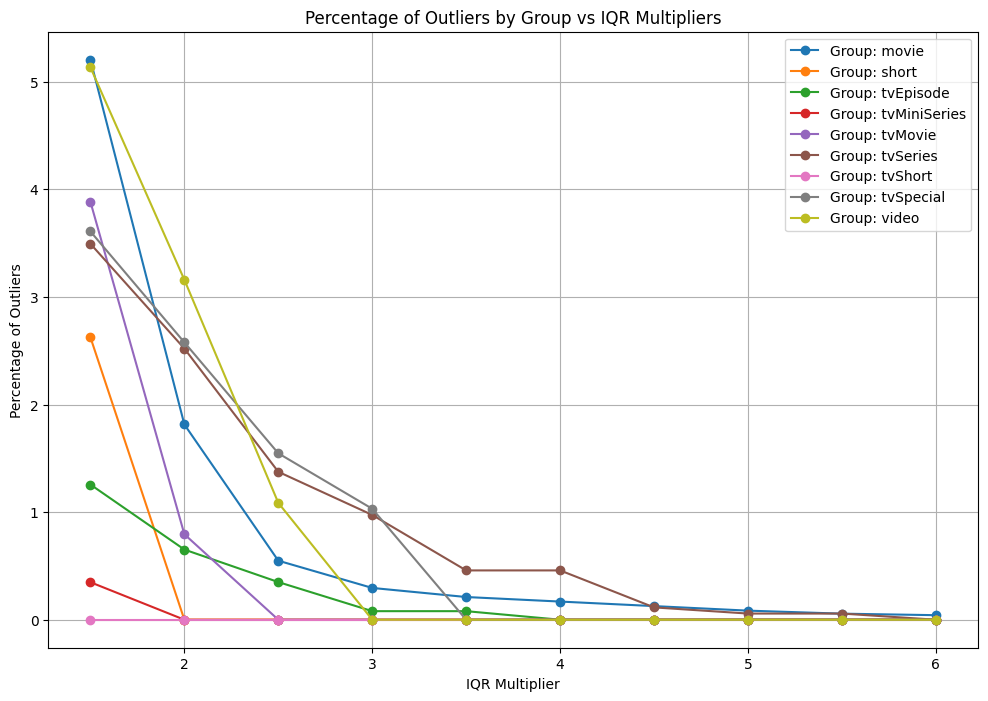

In [26]:
iqrs = [1.5,2,2.5,3,3.5,4,4.5,5,5.5,6]
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_scaled_union_runtimeMinutes.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "runtimeMinutes", "titleType", iqrs, output_file, show_plot=True)

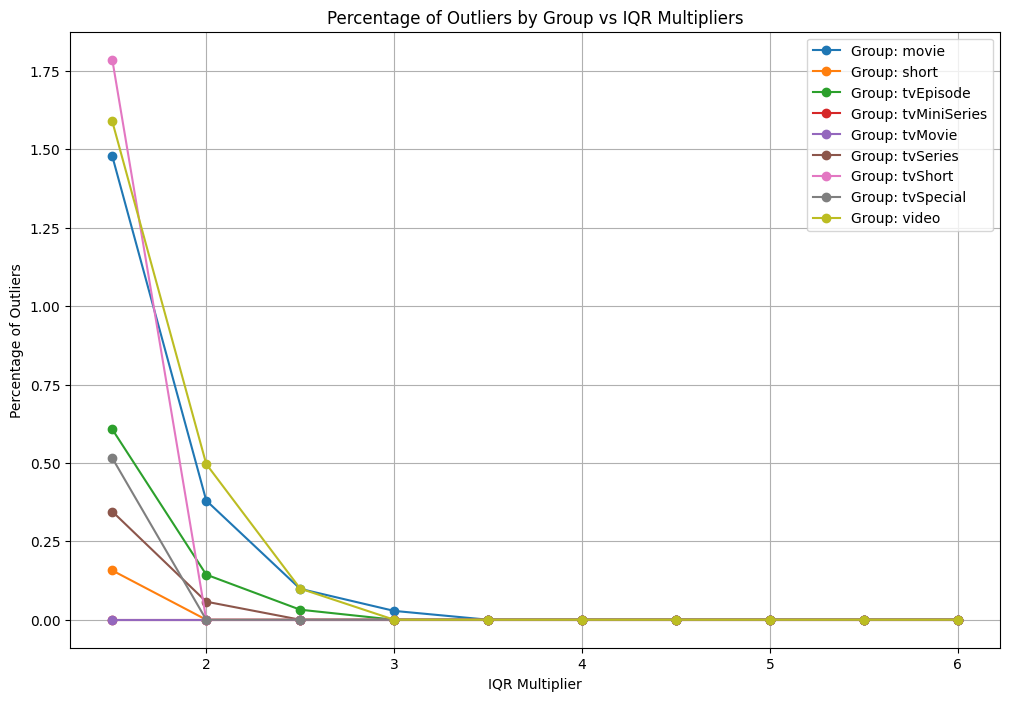

In [27]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_totalCredits.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "totalCredits", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)

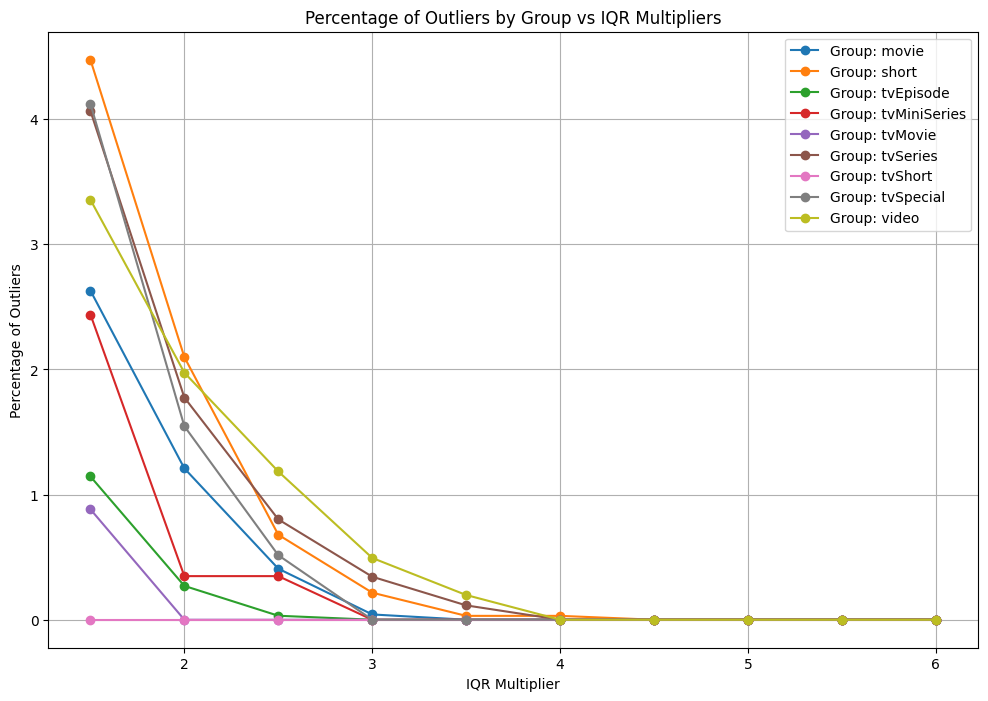

In [28]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_numVotes.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "numVotes", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)

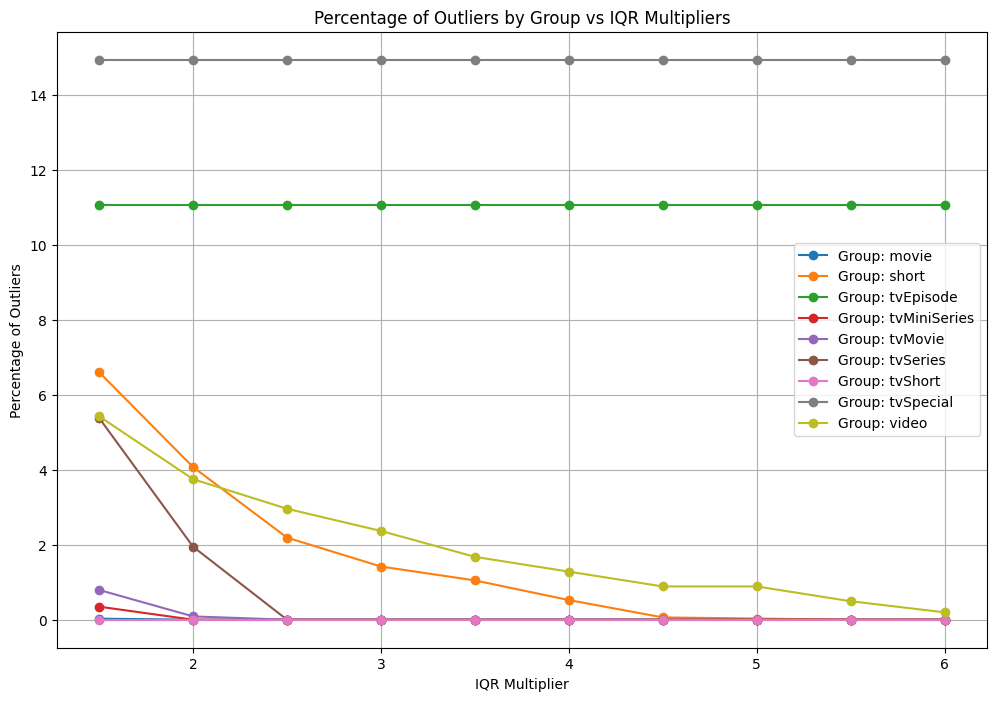

In [29]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_numRegions.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "numRegions", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)

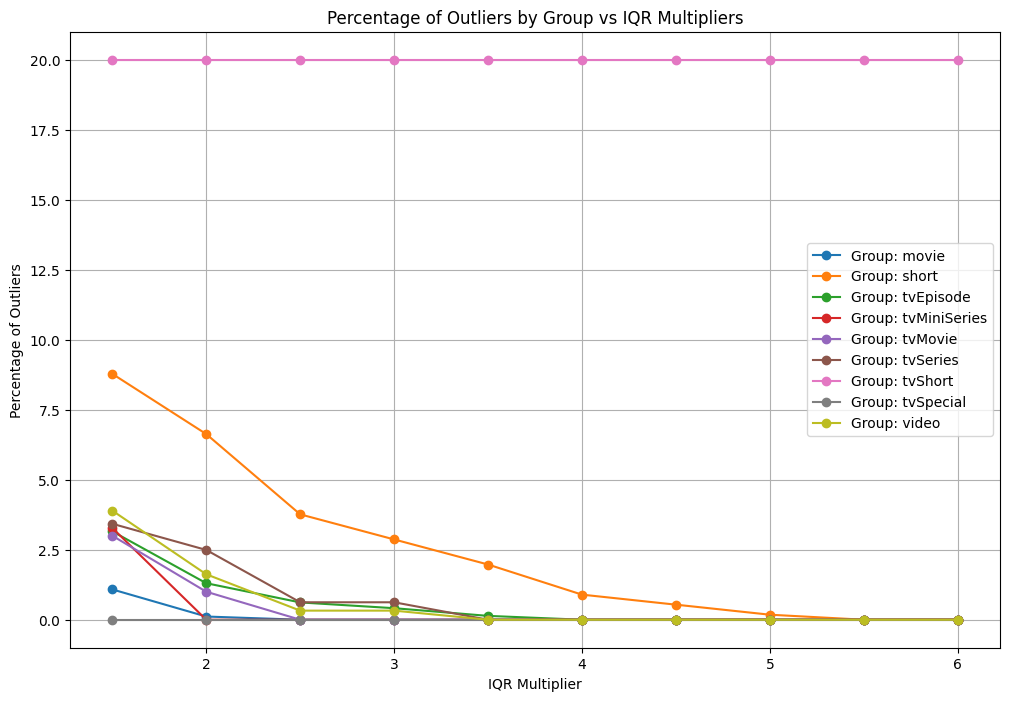

In [30]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_criticReviewsTotal.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "criticReviewsTotal", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)

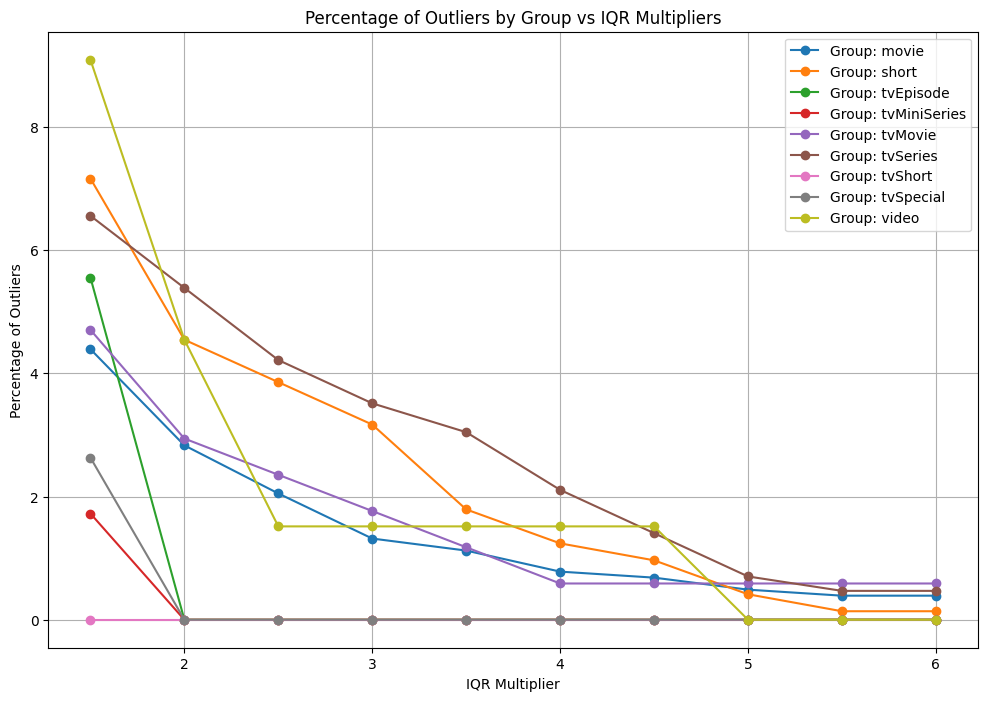

In [31]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_nominations.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "totalRecognitions", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)

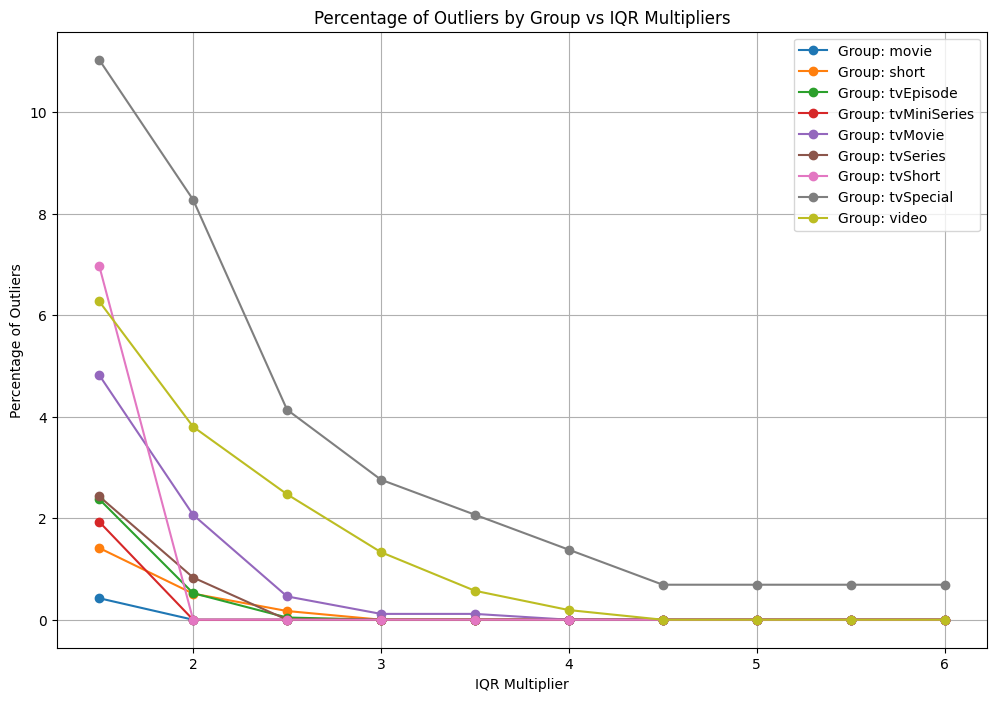

In [32]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_totalMedia.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "totalMedia", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)

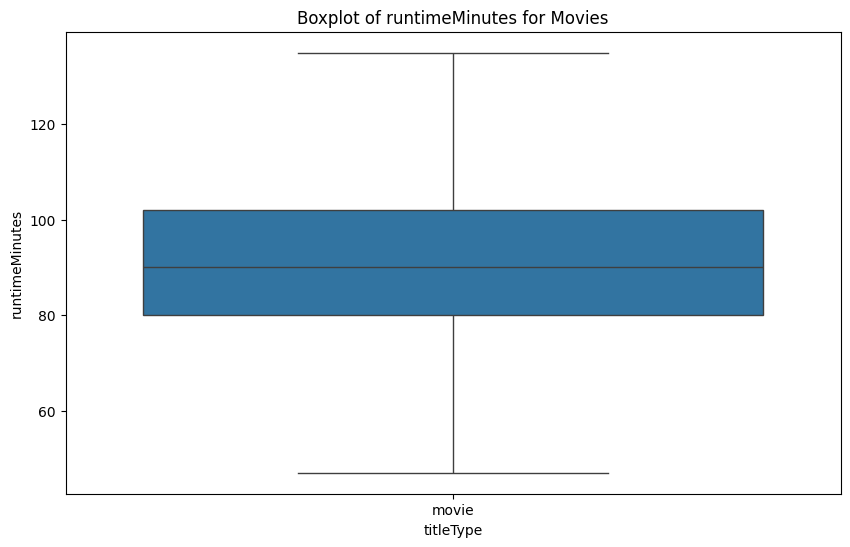

Number of missing values in runtimeMinutes column: 4409
Total number of entries in the dataset: 15802


In [33]:
# print a boxplot of runTimeMinutes and titleType = movie
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_train[data_train["titleType"] == "movie"], x="titleType", y="runtimeMinutes", showfliers=False)
plt.title("Boxplot of runtimeMinutes for Movies")
plt.ylabel("runtimeMinutes")
plt.show()

# print number of missing values in the plot and number of entries in the dataset
print("Number of missing values in runtimeMinutes column:", data_train["runtimeMinutes"].isna().sum())
print("Total number of entries in the dataset:", len(data_train))


# Outliers eliminations

In [34]:
import pandas as pd

def add_outlier_column(data_train, data_test, data_normalized_train, data_normalized_test):
    """
    Aggiunge una colonna 'outlier' con valori iniziali impostati a 0 nei quattro dataset.

    Args:
        data_train (pd.DataFrame): Dataset di addestramento originale.
        data_test (pd.DataFrame): Dataset di test originale.
        data_normalized_train (pd.DataFrame): Dataset di addestramento normalizzato.
        data_normalized_test (pd.DataFrame): Dataset di test normalizzato.

    Returns:
        tuple: Quattro DataFrame con la nuova colonna 'outlier'.
    """
    data_train['outlier'] = 0
    data_test['outlier'] = 0
    data_normalized_train['outlier'] = 0
    data_normalized_test['outlier'] = 0
    return data_train, data_test, data_normalized_train, data_normalized_test


def mark_outliers_iqr_by_group(data_train, data_test, data_normalized_train, data_normalized_test, column, group_column, iqr_multiplier=1.5, remove_both_sides=True):
    """
    Identifica gli outlier utilizzando l'IQR specificato per ciascun gruppo definito da group_column
    e imposta a 1 la colonna 'outlier' nei quattro dataset.

    Args:
        data_train (pd.DataFrame): Dataset di addestramento originale con colonna 'outlier'.
        data_test (pd.DataFrame): Dataset di test originale con colonna 'outlier'.
        data_normalized_train (pd.DataFrame): Dataset di addestramento normalizzato con colonna 'outlier'.
        data_normalized_test (pd.DataFrame): Dataset di test normalizzato con colonna 'outlier'.
        column (str): Colonna su cui calcolare gli outlier.
        group_column (str): Colonna per effettuare il group_by.
        iqr_multiplier (float): Moltiplicatore per definire i limiti degli outlier.
        remove_both_sides (bool): Se True, rileva outlier superiori e inferiori; se False, solo superiori.

    Returns:
        None: Modifica i dataset in-place.
    """
    # Unisce i dati normalizzati per un calcolo combinato per ciascun gruppo
    combined_data = pd.concat([
        data_normalized_train[[group_column, column]],
        data_normalized_test[[group_column, column]]
    ], ignore_index=True)

    # Identifica i gruppi
    groups = combined_data[group_column].unique()

    # Itera sui gruppi
    for group in groups:
        # Filtra i dati del gruppo
        group_data = combined_data[combined_data[group_column] == group]

        # Escludi temporaneamente valori nulli e zeri per il calcolo dell'IQR
        if remove_both_sides:
            non_null_data = group_data[column][group_data[column].notnull()]
        else:
            non_null_data = group_data[column][group_data[column].notnull() & (group_data[column] != 0)]

        if non_null_data.empty:
            continue

        q1 = non_null_data.quantile(0.25)
        q3 = non_null_data.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - iqr_multiplier * iqr if remove_both_sides else float('-inf')
        upper_bound = q3 + iqr_multiplier * iqr

        # Funzione helper per identificare gli outlier
        def is_outlier(value):
            return value < lower_bound or value > upper_bound

        # Identifica gli outlier per il gruppo nei dataset normalizzati
        normalized_train_outliers = data_normalized_train[
            (data_normalized_train[group_column] == group)
        ][column].apply(is_outlier)

        normalized_test_outliers = data_normalized_test[
            (data_normalized_test[group_column] == group)
        ][column].apply(is_outlier)

        # Aggiorna la colonna 'outlier' nei dataset normalizzati
        data_normalized_train.loc[data_normalized_train[group_column] == group, 'outlier'] |= normalized_train_outliers.astype(int)
        data_normalized_test.loc[data_normalized_test[group_column] == group, 'outlier'] |= normalized_test_outliers.astype(int)

        # Conta gli outlier per gruppo
        group_train_outliers = normalized_train_outliers.sum()
        group_test_outliers = normalized_test_outliers.sum()

        print(f"Gruppo '{group}': {group_train_outliers} outlier trovati nel dataset di addestramento normalizzato, {group_test_outliers} outlier trovati nel dataset di test normalizzato.")

    # Propaga gli outlier ai dataset originali
    data_train['outlier'] = data_train['outlier'] | data_normalized_train['outlier']
    data_test['outlier'] = data_test['outlier'] | data_normalized_test['outlier']

    # Conta gli outlier
    train_outliers = data_train['outlier'].sum()
    test_outliers = data_test['outlier'].sum()

    # Stampa i risultati
    print(f"Outlier trovati nel dataset di addestramento originale: {train_outliers}")
    print(f"Outlier trovati nel dataset di test originale: {test_outliers}")



def remove_outliers(data_train, data_test, data_normalized_train, data_normalized_test):
    """
    Elimina le righe marcate come outlier (colonna 'outlier' = 1) dai quattro dataset.

    Args:
        data_train (pd.DataFrame): Dataset di addestramento con colonna 'outlier'.
        data_test (pd.DataFrame): Dataset di test con colonna 'outlier'.
        data_normalized_train (pd.DataFrame): Dataset di addestramento normalizzato con colonna 'outlier'.
        data_normalized_test (pd.DataFrame): Dataset di test normalizzato con colonna 'outlier'.

    Returns:
        tuple: Quattro DataFrame senza outlier.
    """
    data_train_cleaned = data_train[data_train['outlier'] == 0].drop(columns=['outlier'])
    data_test_cleaned = data_test[data_test['outlier'] == 0].drop(columns=['outlier'])
    data_normalized_train_cleaned = data_normalized_train[data_normalized_train['outlier'] == 0].drop(columns=['outlier'])
    data_normalized_test_cleaned = data_normalized_test[data_normalized_test['outlier'] == 0].drop(columns=['outlier'])

    print("Righe eliminate:")
    print(f"Dataset di addestramento: {len(data_train) - len(data_train_cleaned)}")
    print(f"Dataset di test: {len(data_test) - len(data_test_cleaned)}")
    print(f"Dataset di addestramento normalizzato: {len(data_normalized_train) - len(data_normalized_train_cleaned)}")
    print(f"Dataset di test normalizzato: {len(data_normalized_test) - len(data_normalized_test_cleaned)}")

    return data_train_cleaned, data_test_cleaned, data_normalized_train_cleaned, data_normalized_test_cleaned


In [35]:
add_outlier_column(data_train, data_test, scaled_train, scaled_test)

_iqr = 1.5

In [36]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "runtimeMinutes","titleType", iqr_multiplier=_iqr, remove_both_sides=True)

Gruppo 'tvEpisode': 62 outlier trovati nel dataset di addestramento normalizzato, 17 outlier trovati nel dataset di test normalizzato.
Gruppo 'movie': 288 outlier trovati nel dataset di addestramento normalizzato, 82 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSeries': 43 outlier trovati nel dataset di addestramento normalizzato, 18 outlier trovati nel dataset di test normalizzato.
Gruppo 'video': 36 outlier trovati nel dataset di addestramento normalizzato, 16 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMiniSeries': 1 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Gruppo 'short': 67 outlier trovati nel dataset di addestramento normalizzato, 19 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMovie': 35 outlier trovati nel dataset di addestramento normalizzato, 9 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSpecial': 6 outlier trovati nel dataset di addestramento no

In [37]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "totalCredits", "titleType", iqr_multiplier=_iqr, remove_both_sides=True)


Gruppo 'tvEpisode': 212 outlier trovati nel dataset di addestramento normalizzato, 70 outlier trovati nel dataset di test normalizzato.
Gruppo 'movie': 139 outlier trovati nel dataset di addestramento normalizzato, 44 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSeries': 13 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Gruppo 'video': 24 outlier trovati nel dataset di addestramento normalizzato, 10 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMiniSeries': 1 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Gruppo 'short': 48 outlier trovati nel dataset di addestramento normalizzato, 15 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMovie': 4 outlier trovati nel dataset di addestramento normalizzato, 3 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSpecial': 1 outlier trovati nel dataset di addestramento nor

In [38]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "numVotes", "titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo 'tvEpisode': 58 outlier trovati nel dataset di addestramento normalizzato, 14 outlier trovati nel dataset di test normalizzato.
Gruppo 'movie': 138 outlier trovati nel dataset di addestramento normalizzato, 49 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSeries': 59 outlier trovati nel dataset di addestramento normalizzato, 12 outlier trovati nel dataset di test normalizzato.
Gruppo 'video': 22 outlier trovati nel dataset di addestramento normalizzato, 12 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMiniSeries': 5 outlier trovati nel dataset di addestramento normalizzato, 2 outlier trovati nel dataset di test normalizzato.
Gruppo 'short': 113 outlier trovati nel dataset di addestramento normalizzato, 32 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMovie': 7 outlier trovati nel dataset di addestramento normalizzato, 3 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSpecial': 6 outlier trovati nel dataset di addestramento no

In [39]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "criticReviewsTotal","titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo 'tvEpisode': 39 outlier trovati nel dataset di addestramento normalizzato, 7 outlier trovati nel dataset di test normalizzato.
Gruppo 'movie': 27 outlier trovati nel dataset di addestramento normalizzato, 11 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSeries': 8 outlier trovati nel dataset di addestramento normalizzato, 3 outlier trovati nel dataset di test normalizzato.
Gruppo 'video': 8 outlier trovati nel dataset di addestramento normalizzato, 4 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMiniSeries': 2 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Gruppo 'short': 40 outlier trovati nel dataset di addestramento normalizzato, 9 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMovie': 5 outlier trovati nel dataset di addestramento normalizzato, 4 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSpecial': 0 outlier trovati nel dataset di addestramento normalizza

In [40]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "totalRecognitions", "titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo 'tvEpisode': 1 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Gruppo 'movie': 72 outlier trovati nel dataset di addestramento normalizzato, 18 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSeries': 22 outlier trovati nel dataset di addestramento normalizzato, 6 outlier trovati nel dataset di test normalizzato.
Gruppo 'video': 4 outlier trovati nel dataset di addestramento normalizzato, 2 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMiniSeries': 1 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Gruppo 'short': 37 outlier trovati nel dataset di addestramento normalizzato, 15 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMovie': 7 outlier trovati nel dataset di addestramento normalizzato, 1 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSpecial': 1 outlier trovati nel dataset di addestramento normalizz

In [41]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "totalMedia", "titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo 'tvEpisode': 75 outlier trovati nel dataset di addestramento normalizzato, 34 outlier trovati nel dataset di test normalizzato.
Gruppo 'movie': 21 outlier trovati nel dataset di addestramento normalizzato, 7 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSeries': 32 outlier trovati nel dataset di addestramento normalizzato, 6 outlier trovati nel dataset di test normalizzato.
Gruppo 'video': 24 outlier trovati nel dataset di addestramento normalizzato, 9 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMiniSeries': 4 outlier trovati nel dataset di addestramento normalizzato, 1 outlier trovati nel dataset di test normalizzato.
Gruppo 'short': 22 outlier trovati nel dataset di addestramento normalizzato, 11 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvMovie': 32 outlier trovati nel dataset di addestramento normalizzato, 10 outlier trovati nel dataset di test normalizzato.
Gruppo 'tvSpecial': 11 outlier trovati nel dataset di addestramento norm

In [42]:
data_train, data_test, scaled_train, scaled_test = remove_outliers(data_train, data_test, scaled_train, scaled_test)

Righe eliminate:
Dataset di addestramento: 1524
Dataset di test: 472
Dataset di addestramento normalizzato: 1524
Dataset di test normalizzato: 472


# Fill missing values with median

In [43]:
def fill_missing_values_with_median(data, column_to_fill, group_by_column):
    """
    Fill missing values in a specified column with the median value of the column grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing the column to fill and the group-by column.
        column_to_fill (str): The column in which to fill missing values.
        group_by_column (str): The column to group by when calculating the median.

    Returns:
        pd.DataFrame: A DataFrame with missing values in the specified column filled.
    """
    # Ensure the columns exist in the dataset
    if column_to_fill not in data.columns:
        raise ValueError(f"Column '{column_to_fill}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Work on a copy of the data to avoid unintended side-effects
    data = data.copy()

    # Replace '\N' with NaN for proper handling of missing values
    data.loc[:, column_to_fill] = pd.to_numeric(data[column_to_fill], errors='coerce')  # Ensure numeric type
    data.loc[:, group_by_column] = data[group_by_column].astype(str)  # Ensure the group-by column is a string

    # Fill missing values with the median of the group
    data.loc[:, column_to_fill] = data.groupby(group_by_column)[column_to_fill].transform(
        lambda x: x.fillna(x.median())
    )

    return data


In [44]:
data_train = fill_missing_values_with_median(data_train, "runtimeMinutes", "titleType")
data_test = fill_missing_values_with_median(data_test, "runtimeMinutes", "titleType")
scaled_train = fill_missing_values_with_median(scaled_train, "runtimeMinutes", "titleType")
scaled_test = fill_missing_values_with_median(scaled_test, "runtimeMinutes", "titleType")

# Correlation

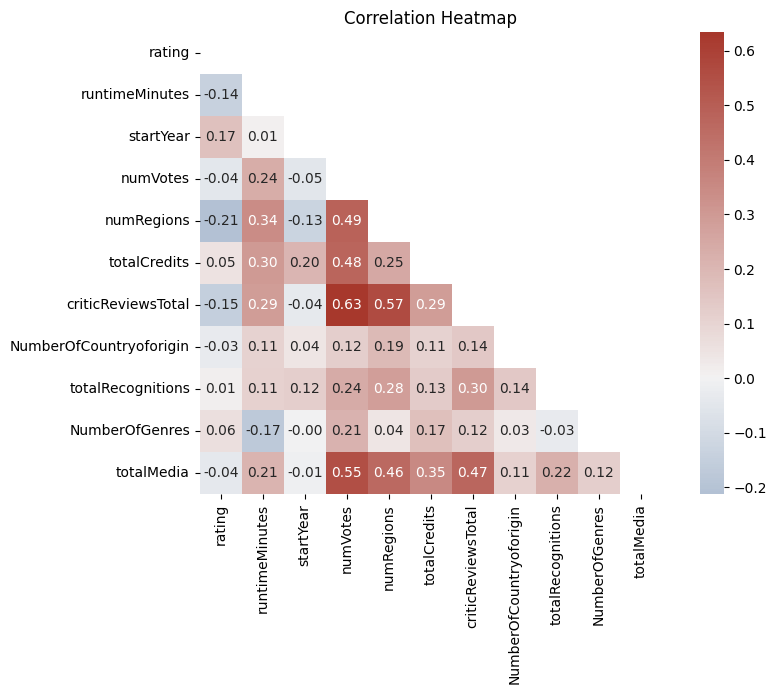

(             Variable 1          Variable 2  Correlation
 39             numVotes  criticReviewsTotal     0.633771
 70   criticReviewsTotal          numRegions     0.566925
 43             numVotes          totalMedia     0.548641
 47           numRegions            numVotes     0.487297
 58         totalCredits            numVotes     0.477861
 76   criticReviewsTotal          totalMedia     0.472242
 114          totalMedia          numRegions     0.461364
 65         totalCredits          totalMedia     0.352611
 15       runtimeMinutes          numRegions     0.340291
 16       runtimeMinutes        totalCredits     0.299998,
                   Variable 1               Variable 2  Correlation
 110               totalMedia                   rating     0.042848
 53                numRegions           NumberOfGenres     0.039923
 28                 startYear       criticReviewsTotal     0.036387
 97         totalRecognitions           NumberOfGenres     0.031769
 106           Number

In [45]:
analyze_correlation(scaled_train, subset_columns, show_plot=True)

# Label Encoding encoding `titleType`

In [46]:
import pandas as pd

def label_encoding(data, column_name, mapping_file, replace_null_with_unknown=False):
    """
    Performs label encoding on a specified column of a DataFrame and saves the mapping of labels to integers.

    Args:
        data (pd.DataFrame): Input DataFrame.
        column_name (str): Column to be label-encoded.
        mapping_file (str): File to save the mapping of labels to integers as key-value pairs.
        replace_null_with_unknown (bool): Replace '\\N' with 'unknown<ColumnName>' if True.

    Returns:
        pd.DataFrame: Updated DataFrame with the label-encoded column.
    """
    # Ensure the specified column is a string and clean it
    data[column_name] = data[column_name].astype(str)

    # Replace '\\N' with 'unknown<ColumnName>' if specified
    if replace_null_with_unknown:
        unknown_value = f"unknown{column_name.capitalize()}"
        data[column_name] = data[column_name].replace(r"\\N", unknown_value, regex=True)

    # Generate a mapping of labels to integers
    unique_labels = data[column_name].unique()
    label_mapping = {label: idx for idx, label in enumerate(sorted(unique_labels))}

    # Save the mapping to a file
    with open(mapping_file, 'w') as f:
        for label, idx in label_mapping.items():
            f.write(f"{label},{idx}\n")

    # Apply label encoding
    data[column_name] = data[column_name].map(label_mapping)

    return data


def merge_txt_files(output_file, *input_files):
    """
    Merges multiple text files into one, removing duplicates and sorting lines.

    Args:
        output_file (str): Path to the output file.
        *input_files (str): Paths to the input files to merge.
    """
    merged_lines = set()
    for file in input_files:
        with open(file, 'r') as f:
            lines = f.read().splitlines()
            for line in lines:
                merged_lines.add(line.strip())

    with open(output_file, 'w') as f:
        for line in sorted(merged_lines):
            f.write(f"{line}\n")

In [47]:
scaled_train = label_encoding(scaled_train, "titleType", 'encoding_lists/titleType_normalized_train.txt')
scaled_test = label_encoding(scaled_test, "titleType", 'encoding_lists/titleType_normalized_test.txt')

merge_txt_files('encoding_lists/titleType_normalized.txt', 'encoding_lists/titleType_normalized_train.txt', 'encoding_lists/titleType_normalized_test.txt')

data_train = label_encoding(data_train, "titleType", 'encoding_lists/titleType_train.txt')
data_test = label_encoding(data_test, "titleType", 'encoding_lists/titleType_test.txt')

merge_txt_files('encoding_lists/titleType.txt', 'encoding_lists/titleType_train.txt', 'encoding_lists/titleType_test.txt')

merge_txt_files('encoding_lists/titleType.txt', 'encoding_lists/titleType.txt', 'encoding_lists/titleType_normalized.txt')

# z-score transformation

In [48]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def zscore_columns(data, columns):
    """
    Applies Z-score normalization on specified columns using StandardScaler from sklearn.

    Args:
        data (pd.DataFrame): The DataFrame on which to apply the normalization.
        columns (list): List of columns to normalize.

    Returns:
        pd.DataFrame: A DataFrame with normalized columns.
    """
    # Initialize the StandardScaler
    scaler = StandardScaler()
    
    # Create a copy of the original DataFrame to avoid modifying it directly
    data_scaled = data.copy()
    
    # Apply StandardScaler only to the specified columns
    data_scaled[columns] = scaler.fit_transform(data[columns])
    
    return data_scaled


In [49]:
scaled_columns = [
    "runtimeMinutes",
    "totalCredits",
    "numVotes",
    "numRegions",
    "criticReviewsTotal",
    "totalRecognitions",
    "totalMedia"
]

scaled_train = zscore_columns(scaled_train, scaled_columns)
scaled_test = zscore_columns(scaled_test, scaled_columns)

In [50]:
# Lista di tutti i paesi dal file countryOfOrigin.txt
with open('encoding_lists/countryoforigin.txt', 'r') as f:
    all_countries = [line.strip() for line in f]

# Aggiungere colonne per i paesi mancanti in train e test
# Per ogni paese assente, aggiungere una colonna con valore 0
for country in all_countries:
    if country not in data_train.columns:
        data_train[country] = 0
    if country not in data_test.columns:
        data_test[country] = 0

# Ordinare solo le colonne corrispondenti ai paesi
data_train = data_train[[col for col in data_train.columns if col not in all_countries] + 
                    [col for col in all_countries if col in data_train.columns]]
data_test = data_test[[col for col in data_test.columns if col not in all_countries] + 
                   [col for col in all_countries if col in data_test.columns]]

# now for the scaled datasets
for country in all_countries:
    if country not in scaled_train.columns:
        scaled_train[country] = 0
    if country not in scaled_test.columns:
        scaled_test[country] = 0

# Ordinare solo le colonne corrispondenti ai paesi
scaled_train = scaled_train[[col for col in scaled_train.columns if col not in all_countries] + 
                    [col for col in all_countries if col in scaled_train.columns]]
scaled_test = scaled_test[[col for col in scaled_test.columns if col not in all_countries] + 
                   [col for col in all_countries if col in scaled_test.columns]]

In [51]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

# store the 4 datasets
store_dataset(data_train, 'data/output/02_data_understanding/clean_data_train')
store_dataset(data_test, 'data/output/02_data_understanding/clean_data_test')
store_dataset(scaled_train, 'data/output/02_data_understanding/clean_normalized_data_train')
store_dataset(scaled_test, 'data/output/02_data_understanding/clean_normalized_data_test')

Dataset successfully stored as data/output/02_data_understanding/clean_data_train.csv
Dataset successfully stored as data/output/02_data_understanding/clean_data_test.csv
Dataset successfully stored as data/output/02_data_understanding/clean_normalized_data_train.csv
Dataset successfully stored as data/output/02_data_understanding/clean_normalized_data_test.csv


'data/output/02_data_understanding/clean_normalized_data_test.csv'